# NFCI research — normalizations + event studies

**Data source**: Chicago Fed National Financial Conditions Index

**Publish schedule** (verified from chicagofed.org):
- Weekly, values dated the **previous Friday**
- Published every **Wednesday 08:30 a.m. ET** (= 20:30 TPE DST / 21:30 TPE standard)
- Thursday if Wed is a US federal holiday

**PIT lag** in `load_nfci_tw`: **6 calendar days** (Fri value → usable from Thursday of week+1). Covers Wed 20:30 TPE publish + one-day Thursday-shift buffer.

This notebook:
1. Loads NFCI aligned to the TW trading calendar (PIT-safe, forward-filled)
2. Tests 8 normalization schemes × 4 raw inputs → 32-cell heatmap of MTX c2c SRs
3. Event study — CAAR + CASR around tightening / loosening shocks
4. Plots cumulative PnL for the top-3 signals

In [100]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import cta

ASSET = cta.load_asset('mtx', '1d')
nfci  = cta.load_nfci_tw('nfci', ASSET.index).dropna()

print(f'MTX 1d:  {len(ASSET)} rows, {ASSET.index.min().date()} → {ASSET.index.max().date()}')
print(f'NFCI TW: {len(nfci)} rows,  {nfci.index.min().date()} → {nfci.index.max().date()}')

ret     = ASSET['close'].pct_change()
cost    = 20.0/(ASSET['close']*50.0) + 0.00002
EVAL_ST = pd.Timestamp('2013-01-01')
EVAL_EN = ASSET.index.max()

MTX 1d:  6230 rows, 2001-04-09 → 2026-07-27
NFCI TW: 6230 rows,  2001-04-09 → 2026-07-27


## PIT verification — NFCI values should only change on Thursdays

In [101]:
# Show last 15 TW dates + NFCI values — transitions should occur on Thursdays only
recent = nfci.iloc[-15:]
for d, v in recent.items():
    print(f'  {d.strftime("%Y-%m-%d %a")}  {v:+.3f}')

  2026-07-06 Mon  -0.511
  2026-07-07 Tue  -0.511
  2026-07-08 Wed  -0.511
  2026-07-09 Thu  -0.525
  2026-07-13 Mon  -0.525
  2026-07-14 Tue  -0.525
  2026-07-15 Wed  -0.525
  2026-07-16 Thu  -0.539
  2026-07-17 Fri  -0.539
  2026-07-20 Mon  -0.539
  2026-07-21 Tue  -0.539
  2026-07-22 Wed  -0.539
  2026-07-23 Thu  -0.552
  2026-07-24 Fri  -0.552
  2026-07-27 Mon  -0.552


## § 1 — Normalization grid: 8 schemes × 4 raw inputs

For each raw input (NFCI level or N-week delta), test 8 ways to collapse into [-1, +1]:

| Norm | Formula | Character |
|---|---|---|
| `raw_tanh` | tanh(x) | direct squash, no rolling |
| `z_tanh` | tanh(rolling_z(x, 252)) | adaptive to regime |
| `z_winsor_c3` | clip(rolling_z, ±3) / 3 | hard bound |
| `z_sigmoid` | logistic(rolling_z) | smooth S-curve |
| `robust_z_tanh` | tanh(MAD-based z) | outlier-resistant |
| `rank_c` | (rolling percentile rank − 0.5) × 2 | non-parametric |
| `sign_thresh_0p5` | ±1 when |z| > 0.5, else 0 | frequent thresholding |
| `sign_thresh_1p0` | ±1 when |z| > 1.0, else 0 | rare thresholding |

In [102]:
def _selfz(x, w):
    mu = x.rolling(w, min_periods=w//4).mean()
    sd = x.rolling(w, min_periods=w//4).std().replace(0, np.nan)
    return (x - mu) / sd

def _robust_z(x, w):
    med = x.rolling(w, min_periods=w//4).median()
    mad = (x - med).abs().rolling(w, min_periods=w//4).median()
    return (x - med) / (1.4826 * mad.replace(0, np.nan))

def _rank_c(x, w):
    return (x.rolling(w, min_periods=w//4).apply(
        lambda a: (pd.Series(a).rank(pct=True).iloc[-1] - 0.5) * 2, raw=False))

NORMS = {
    'raw_tanh':        lambda x, w: np.tanh(x),
    'z_tanh':          lambda x, w: np.tanh(_selfz(x, w)),
    'z_winsor_c3':     lambda x, w: _selfz(x, w).clip(-3, 3) / 3,
    'z_sigmoid':       lambda x, w: 2 / (1 + np.exp(-_selfz(x, w))) - 1,
    'robust_z_tanh':   lambda x, w: np.tanh(_robust_z(x, w)),
    'rank_c':          _rank_c,
    'sign_thresh_0p5': lambda x, w: pd.Series(
        np.where(_selfz(x, w) > 0.5, 1.0,
                 np.where(_selfz(x, w) < -0.5, -1.0, 0.0)), index=x.index),
    'sign_thresh_1p0': lambda x, w: pd.Series(
        np.where(_selfz(x, w) > 1.0, 1.0,
                 np.where(_selfz(x, w) < -1.0, -1.0, 0.0)), index=x.index),
}

W = 252
INPUTS = {
    'level':    nfci,
    'delta_1w': nfci.diff(5),
    'delta_2w': nfci.diff(10),
    'delta_4w': nfci.diff(20),
}

def _pnl(sig):
    ex = sig.reindex(ASSET.index).shift(2)
    return (ex*ret - ex.fillna(0).diff().abs()*cost).loc[EVAL_ST:EVAL_EN].dropna()

def _sr(p):
    return float(np.sqrt(252) * p.mean() / p.std()) if len(p) > 30 and p.std() > 0 else np.nan

In [103]:
rows = []
for input_name, x in INPUTS.items():
    for norm_name, fn in NORMS.items():
        sig  = fn(x, W)
        p_p  = _pnl(sig); p_n = _pnl(-sig)
        sr_p, sr_n = _sr(p_p), _sr(p_n)
        best_sr   = max(sr_p, sr_n) if not (np.isnan(sr_p) and np.isnan(sr_n)) else np.nan
        best_sign = '+' if sr_p >= sr_n else '-'
        best_pnl  = p_p if sr_p >= sr_n else p_n
        rows.append({
            'input': input_name, 'norm': norm_name,
            'SR_pos': round(sr_p, 3) if not np.isnan(sr_p) else None,
            'SR_neg': round(sr_n, 3) if not np.isnan(sr_n) else None,
            'best_SR': round(best_sr, 3) if not np.isnan(best_sr) else None,
            'sign': best_sign,
            'ann_ret%': round(float(best_pnl.mean()*252*100), 2) if len(best_pnl) else None,
            'max_dd%':  round(float((best_pnl.cumsum()-best_pnl.cumsum().cummax()).min()*100), 2) if len(best_pnl) else None,
        })

grid = pd.DataFrame(rows)
grid.sort_values('best_SR', ascending=False).head(10)

,input,norm,SR_pos,SR_neg,best_SR,sign,ann_ret%,max_dd%
15,delta_1w,sign_thresh_1p0,-0.792,0.783,0.783,-,9.83,-22.19
11,delta_1w,z_sigmoid,-0.790,0.780,0.780,-,7.83,-21.98
10,delta_1w,z_winsor_c3,-0.783,0.773,0.773,-,7.00,-21.98
0,level,raw_tanh,-0.769,0.769,0.769,-,6.07,-14.41
9,delta_1w,z_tanh,-0.763,0.753,0.753,-,9.95,-24.91
17,delta_2w,z_tanh,-0.718,0.709,0.709,-,9.45,-23.81
14,delta_1w,sign_thresh_0p5,-0.699,0.690,0.690,-,10.46,-30.45
19,delta_2w,z_sigmoid,-0.695,0.686,0.686,-,6.99,-22.05
7,level,sign_thresh_1p0,-0.654,0.651,0.651,-,8.28,-39.82
13,delta_1w,rank_c,-0.660,0.650,0.650,-,8.32,-25.62


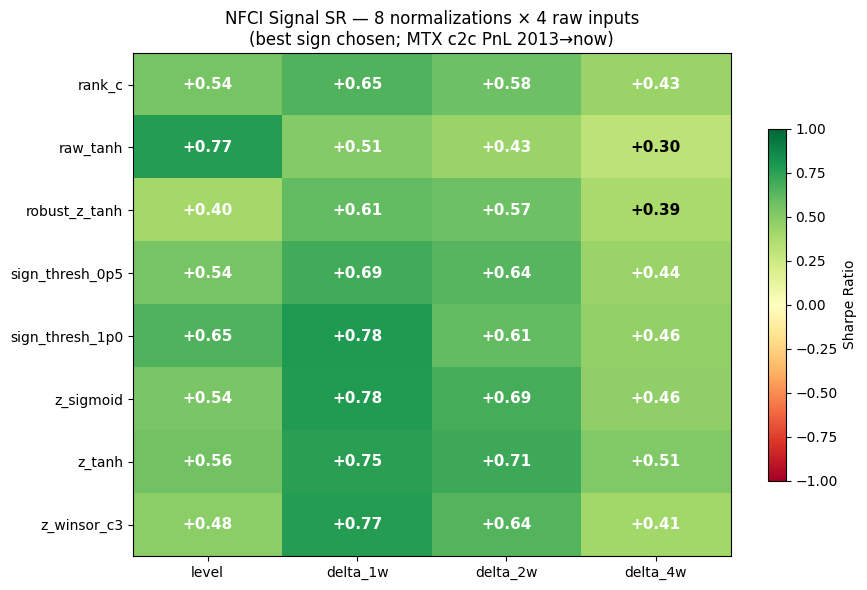

In [104]:
# Heatmap of best_SR
piv = grid.pivot(index='norm', columns='input', values='best_SR')
piv = piv[['level', 'delta_1w', 'delta_2w', 'delta_4w']]

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(piv.values, aspect='auto', cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i, j]
        if pd.notna(v):
            ax.text(j, i, f'{v:+.2f}', ha='center', va='center',
                    color='white' if abs(v) > 0.4 else 'black', fontsize=11, fontweight='bold')
ax.set_title(f'NFCI Signal SR — {len(NORMS)} normalizations × {len(INPUTS)} raw inputs\n(best sign chosen; MTX c2c PnL 2013→now)')
plt.colorbar(im, ax=ax, shrink=0.7, label='Sharpe Ratio')
plt.tight_layout(); plt.show()

## § 2 — Event study: CAAR + CASR around NFCI shocks

**Event definition**: a Friday where the weekly Δ_1w is more than ±1σ of its rolling 52-week std.

**Window**: -10 to +30 TW trading days from the event's earliest observable TW date (Fri + 6d).

**Metrics**:
- **CAAR** — cumulative average abnormal return = mean(cumulative daily return) across events
- **CASR** — t-statistic = CAAR / (std / √N). Values > ±1.96 = statistically significant at p=0.05.

In [78]:
nfci_weekly = cta.load_nfci('nfci')
delta_1w    = nfci_weekly.diff()
sigma       = delta_1w.rolling(52, min_periods=13).std()

tight_events = delta_1w[delta_1w >  1 * sigma].index
loose_events = delta_1w[delta_1w < -1 * sigma].index

# Filter to eval window (2013+)
tight_events = tight_events[tight_events >= EVAL_ST]
loose_events = loose_events[loose_events >= EVAL_ST]
print(f'Post-2013 tightening shocks: {len(tight_events)}')
print(f'Post-2013 loosening shocks:  {len(loose_events)}')

Post-2013 tightening shocks: 120
Post-2013 loosening shocks:  107


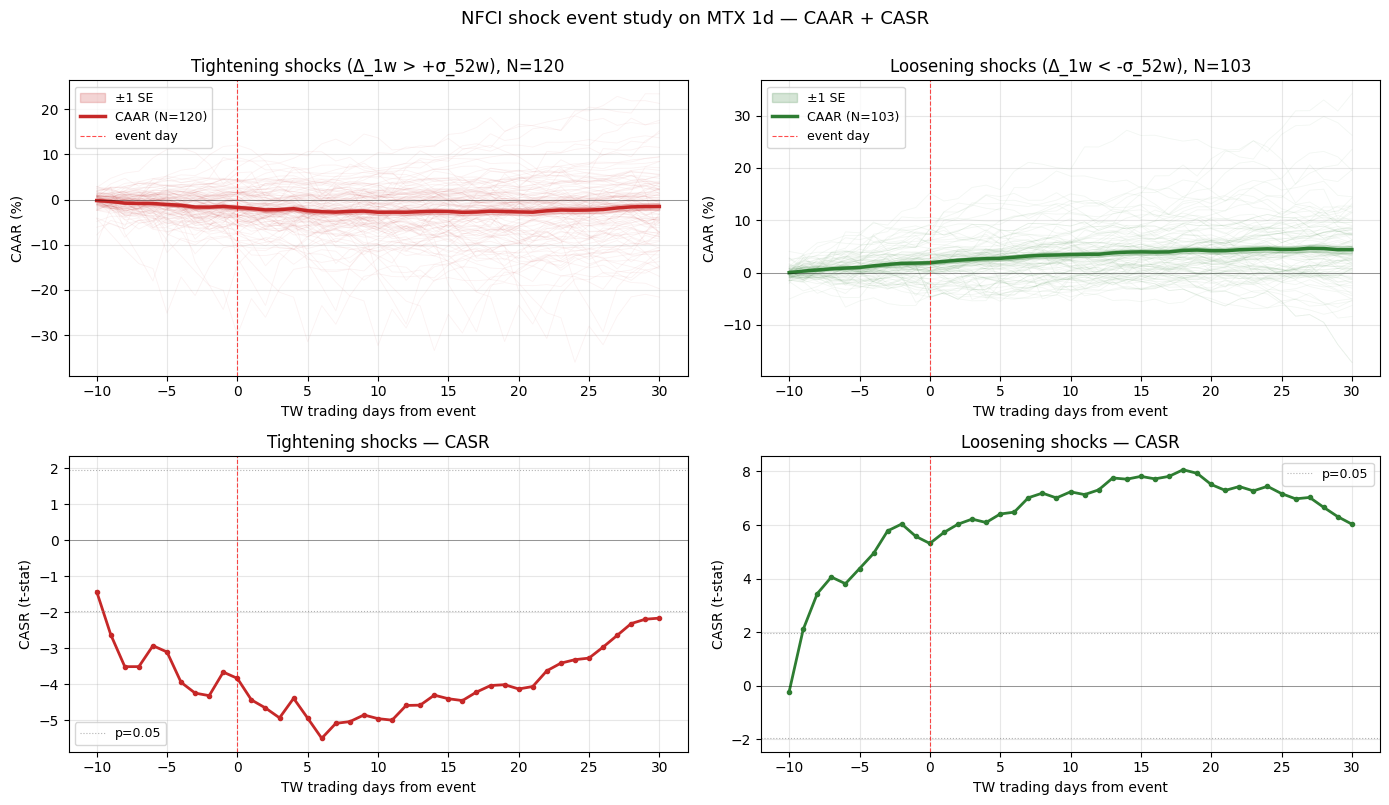

In [79]:
WIN_PRE, WIN_POST = 10, 30

def _event_car(event_dates, ret_series, pre, post):
    car_rows = []
    tw_index = ret_series.index
    for ev in event_dates:
        exec_date = ev + pd.Timedelta(days=6)
        pos = tw_index.searchsorted(exec_date, side='left')
        if pos < pre or pos >= len(tw_index) - post: continue
        window_idx = tw_index[pos-pre : pos+post+1]
        r_win = ret_series.reindex(window_idx).fillna(0).values
        car_rows.append(r_win.cumsum())
    return np.array(car_rows) if car_rows else np.zeros((0, pre+post+1))

def _caar_casr(car_matrix):
    if car_matrix.shape[0] == 0: return None, None, None
    caar = car_matrix.mean(axis=0) * 100
    std  = car_matrix.std(axis=0) * 100
    casr = caar / (std / np.sqrt(car_matrix.shape[0]))
    return caar, std, casr

tight_car = _event_car(tight_events, ret, WIN_PRE, WIN_POST)
loose_car = _event_car(loose_events, ret, WIN_PRE, WIN_POST)
t_caar, t_std, t_casr = _caar_casr(tight_car)
l_caar, l_std, l_casr = _caar_casr(loose_car)

xs = np.arange(-WIN_PRE, WIN_POST+1)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

def _plot_car(ax, xs, car_mat, caar, std, casr, title, color):
    for row in car_mat:
        ax.plot(xs, row*100, color=color, alpha=0.06, lw=0.6)
    ax.fill_between(xs, caar - std/np.sqrt(len(car_mat)),
                        caar + std/np.sqrt(len(car_mat)),
                    color=color, alpha=0.2, label='±1 SE')
    ax.plot(xs, caar, color=color, lw=2.5, label=f'CAAR (N={len(car_mat)})')
    ax.axhline(0, color='black', lw=0.5, alpha=0.5)
    ax.axvline(0, color='red',   lw=0.8, ls='--', alpha=0.7, label='event day')
    ax.set_xlabel('TW trading days from event'); ax.set_ylabel('CAAR (%)')
    ax.set_title(title); ax.legend(fontsize=9); ax.grid(alpha=0.3)

def _plot_casr(ax, xs, casr, title, color):
    ax.plot(xs, casr, color=color, lw=2, marker='o', ms=3)
    ax.axhline( 0,    color='black', lw=0.5, alpha=0.5)
    ax.axhline( 1.96, color='grey',  lw=0.8, ls=':', alpha=0.6, label='p=0.05')
    ax.axhline(-1.96, color='grey',  lw=0.8, ls=':', alpha=0.6)
    ax.axvline( 0,    color='red',   lw=0.8, ls='--', alpha=0.7)
    ax.set_xlabel('TW trading days from event'); ax.set_ylabel('CASR (t-stat)')
    ax.set_title(title); ax.legend(fontsize=9); ax.grid(alpha=0.3)

_plot_car( axes[0,0], xs, tight_car, t_caar, t_std, t_casr,
           f'Tightening shocks (Δ_1w > +σ_52w), N={len(tight_car)}', '#C62828')
_plot_car( axes[0,1], xs, loose_car, l_caar, l_std, l_casr,
           f'Loosening shocks (Δ_1w < -σ_52w), N={len(loose_car)}',  '#2E7D32')
_plot_casr(axes[1,0], xs, t_casr, 'Tightening shocks — CASR', '#C62828')
_plot_casr(axes[1,1], xs, l_casr, 'Loosening shocks — CASR',  '#2E7D32')

plt.suptitle('NFCI shock event study on MTX 1d — CAAR + CASR', fontsize=13, y=1.00)
plt.tight_layout(); plt.show()

## § 3 — Top-3 signal cumulative PnL

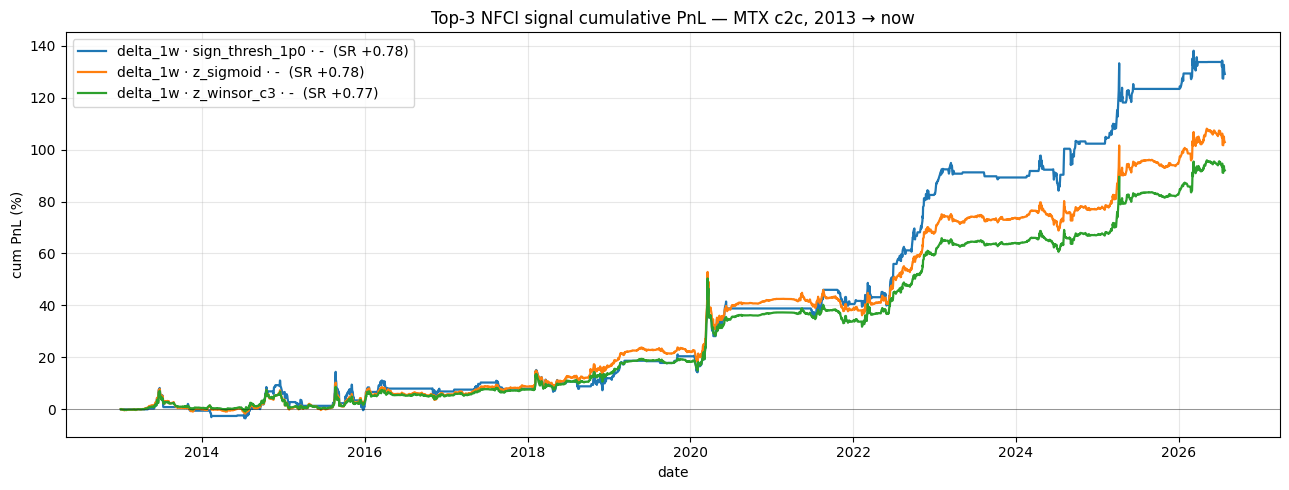

In [80]:
top3 = grid.dropna(subset=['best_SR']).sort_values('best_SR', ascending=False).head(3)

fig, ax = plt.subplots(figsize=(13, 5))
for _, row in top3.iterrows():
    inp = INPUTS[row['input']]
    fn  = NORMS[row['norm']]
    sig = fn(inp, W) * (1 if row['sign'] == '+' else -1)
    p = _pnl(sig)
    ax.plot(p.cumsum().index, p.cumsum().values * 100, lw=1.6,
            label=f"{row['input']} · {row['norm']} · {row['sign']}  (SR {row['best_SR']:+.2f})")

ax.axhline(0, color='black', lw=0.5, alpha=0.5)
ax.set_ylabel('cum PnL (%)'); ax.set_xlabel('date')
ax.set_title('Top-3 NFCI signal cumulative PnL — MTX c2c, 2013 → now')
ax.legend(fontsize=10, loc='upper left'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## § 4 — Search for DENSE NFCI signals

The dropped sparse event signals had SR ~1.5-1.9 with < 1% ann_ret because they only fired on ~20% of trading days. That's not tradeable and easy to overfit.

Focus here: only signals with **100% coverage** (or ≥ 80% coverage) that carry real risk-adjusted return. Ideas to test:

1. **Longer / mixed delta windows** — Δ_2w, Δ_4w, Δ_8w, and combinations (short − long)
2. **Sub-index mixes** — headline NFCI × ANFCI, or credit_delta × risk_delta
3. **Cross-signals with existing sources** — NFCI × SOX momentum, NFCI × TAIEX momentum
4. **NFCI-conditional scaling** — take existing MTX signal, multiply position size by (1 − NFCI-regime)
5. **NFCI-regime timed** — long TW when NFCI is falling AND below its 26-week average; short otherwise

All of these can be continuous with 100% coverage. Use the scratch cell below to prototype.

In [81]:
# ── § 4 scratch: helper to score any dense signal ─────────────────────────
# All new signals here MUST have coverage ≥ 80% (n_active / n_days).

def _score_dense(sig, name):
    ex = sig.reindex(ASSET.index).shift(2)
    p  = (ex*ret - ex.fillna(0).diff().abs()*cost).loc[EVAL_ST:EVAL_EN].dropna()
    if len(p) < 30 or p.std() == 0:
        return None
    coverage = (ex.abs() > 1e-8).sum() / len(ex)
    return {
        'signal':    name,
        'SR':        round(float(np.sqrt(252)*p.mean()/p.std()), 3),
        'ann_ret%':  round(float(p.mean()*252*100), 2),
        'ann_vol%':  round(float(p.std()*np.sqrt(252)*100), 2),
        'max_dd%':   round(float((p.cumsum()-p.cumsum().cummax()).min()*100), 2),
        'coverage%': round(coverage * 100, 1),
    }

# Load sub-indices upfront for combined signals
sub = {
    'nfci':       nfci,
    'anfci':      cta.load_nfci_tw('anfci',      ASSET.index),
    'credit':     cta.load_nfci_tw('credit',     ASSET.index),
    'risk':       cta.load_nfci_tw('risk',       ASSET.index),
    'leverage':   cta.load_nfci_tw('leverage',   ASSET.index),
    'nonfin_lev': cta.load_nfci_tw('nonfin_lev', ASSET.index),
}
print('loaded sub-indices:', list(sub.keys()))

loaded sub-indices: ['nfci', 'anfci', 'credit', 'risk', 'leverage', 'nonfin_lev']


### § 4.1 — Sub-index expansion (each sub-index × § 1's 32-cell grid)

Currently the top baseline is `delta_1w × sign_thresh_1p0 × sign(−)` on the headline NFCI at SR 0.78. We haven't touched the 5 sub-indices at all. This cell runs the same 8-normalization × 4-input grid on each of them, giving 8 × 4 × 6 = **192 factor candidates**. All 100% coverage. All PIT-safe.

Each sub-index has a different economic meaning:
- `nfci` — headline (all 105 raw indicators)
- `anfci` — adjusted for macro state (removes business-cycle influence)
- `credit` — credit conditions subindex
- `risk` — risk / VIX-like subindex
- `leverage` — financial-sector leverage
- `nonfin_lev` — non-financial-sector leverage

In [82]:
# Run the § 1 grid × all 6 sub-indices (192 factors)
sub_grid = []
for sub_name, sub_series in sub.items():
    inputs = {
        f'{sub_name}_level':    sub_series,
        f'{sub_name}_delta_1w': sub_series.diff(5),
        f'{sub_name}_delta_2w': sub_series.diff(10),
        f'{sub_name}_delta_4w': sub_series.diff(20),
    }
    for input_name, x in inputs.items():
        for norm_name, fn in NORMS.items():
            sig = fn(x, W)
            p_p = _pnl(sig); p_n = _pnl(-sig)
            sr_p, sr_n = _sr(p_p), _sr(p_n)
            best_sr = max(sr_p, sr_n) if not (np.isnan(sr_p) and np.isnan(sr_n)) else np.nan
            best_sign = '+' if sr_p >= sr_n else '-'
            sub_grid.append({
                'sub_index': sub_name,
                'input':     input_name.split('_', 1)[1],
                'norm':      norm_name,
                'best_SR':   round(best_sr, 3) if not np.isnan(best_sr) else None,
                'sign':      best_sign,
            })

sub_grid_df = pd.DataFrame(sub_grid).sort_values('best_SR', ascending=False, na_position='last')
print(f'=== Top-15 factors across {len(sub_grid_df)} sub-index × input × norm combos ===\n')
sub_grid_df.head(15)

=== Top-15 factors across 192 sub-index × input × norm combos ===



,sub_index,input,norm,best_SR,sign
73,credit,delta_1w,z_tanh,0.882,-
76,credit,delta_1w,robust_z_tanh,0.874,-
75,credit,delta_1w,z_sigmoid,0.860,-
77,credit,delta_1w,rank_c,0.835,-
160,nonfin_lev,lev_level,raw_tanh,0.833,-
74,credit,delta_1w,z_winsor_c3,0.827,-
96,risk,level,raw_tanh,0.824,-
81,credit,delta_2w,z_tanh,0.819,-
15,nfci,delta_1w,sign_thresh_1p0,0.783,-
11,nfci,delta_1w,z_sigmoid,0.780,-


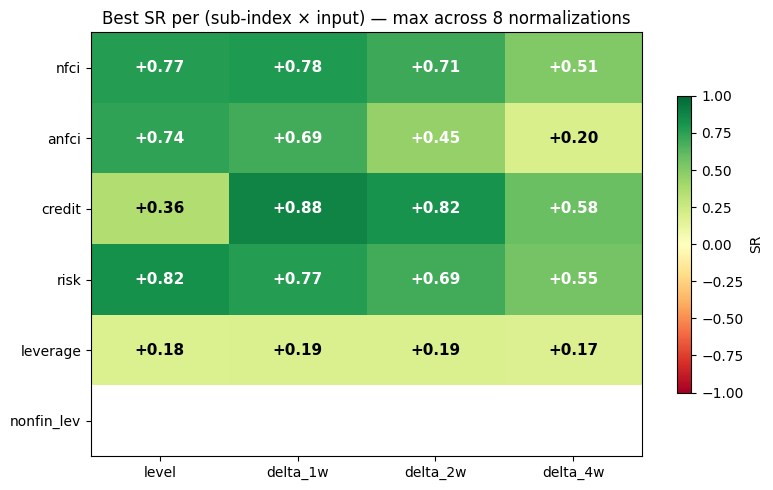

In [83]:
# Heatmap: for each (sub_index × input) combo, the best_SR across normalizations
piv = sub_grid_df.groupby(['sub_index', 'input'])['best_SR'].max().unstack()
piv = piv[['level', 'delta_1w', 'delta_2w', 'delta_4w']]
piv = piv.reindex(['nfci','anfci','credit','risk','leverage','nonfin_lev'])

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(piv.values, aspect='auto', cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i, j]
        if pd.notna(v):
            ax.text(j, i, f'{v:+.2f}', ha='center', va='center',
                    color='white' if abs(v) > 0.4 else 'black', fontsize=11, fontweight='bold')
ax.set_title('Best SR per (sub-index × input) — max across 8 normalizations')
plt.colorbar(im, ax=ax, shrink=0.7, label='SR')
plt.tight_layout(); plt.show()

### § 4.2 — Divergence factors (headline − sub-index)

**Idea:** when the headline NFCI moves but a sub-index doesn't (or vice versa), it might signal early regime change. E.g., if `credit` is worsening but headline is flat, the market may not have priced the coming stress yet.

We construct `diverge[X] = z(NFCI) − z(X)` — the standardized gap between headline and each sub-index.

In [84]:
# Divergence: z(nfci_level) - z(sub_level), plus its delta over 1w and 4w
div_rows = []
z_nfci = _selfz(sub['nfci'], W)
for sub_name in ['anfci','credit','risk','leverage','nonfin_lev']:
    z_sub  = _selfz(sub[sub_name], W)
    div    = z_nfci - z_sub
    inputs = {
        'diverge_level':    div,
        'diverge_delta_1w': div.diff(5),
        'diverge_delta_4w': div.diff(20),
    }
    for input_name, x in inputs.items():
        for norm_name, fn in NORMS.items():
            sig = fn(x, W)
            p_p = _pnl(sig); p_n = _pnl(-sig)
            sr_p, sr_n = _sr(p_p), _sr(p_n)
            best_sr = max(sr_p, sr_n) if not (np.isnan(sr_p) and np.isnan(sr_n)) else np.nan
            best_sign = '+' if sr_p >= sr_n else '-'
            div_rows.append({
                'pair':      f'nfci − {sub_name}',
                'input':     input_name,
                'norm':      norm_name,
                'best_SR':   round(best_sr, 3) if not np.isnan(best_sr) else None,
                'sign':      best_sign,
            })

div_df = pd.DataFrame(div_rows).sort_values('best_SR', ascending=False, na_position='last')
print(f'=== Top-10 divergence factors ({len(div_df)} candidates) ===\n')
div_df.head(10)

=== Top-10 divergence factors (120 candidates) ===



,pair,input,norm,best_SR,sign
104,nfci − nonfin_lev,diverge_delta_1w,raw_tanh,0.850,-
110,nfci − nonfin_lev,diverge_delta_1w,sign_thresh_0p5,0.816,-
16,nfci − anfci,diverge_delta_4w,raw_tanh,0.732,-
17,nfci − anfci,diverge_delta_4w,z_tanh,0.711,-
22,nfci − anfci,diverge_delta_4w,sign_thresh_0p5,0.709,-
80,nfci − leverage,diverge_delta_1w,raw_tanh,0.708,-
108,nfci − nonfin_lev,diverge_delta_1w,robust_z_tanh,0.704,-
19,nfci − anfci,diverge_delta_4w,z_sigmoid,0.689,-
107,nfci − nonfin_lev,diverge_delta_1w,z_sigmoid,0.671,-
105,nfci − nonfin_lev,diverge_delta_1w,z_tanh,0.667,-


### § 4.3 — Cross-timescale factors (fast delta − slow delta)

**Idea:** the difference between short-term and long-term change captures **acceleration**. When 1-week Δ is falling fast while 12-week Δ is still positive, you're at a turning point.

`accel[X] = z(Δ_1w(X)) − z(Δ_12w(X))` — how much faster is the recent change than the medium-term trend.

In [85]:
# Acceleration: z(delta_fast) - z(delta_slow) per sub-index
accel_rows = []
for sub_name, sub_series in sub.items():
    for fast, slow in [(5, 20), (5, 60), (10, 60), (10, 120)]:   # 1w-4w, 1w-12w, 2w-12w, 2w-24w
        z_fast = _selfz(sub_series.diff(fast), W)
        z_slow = _selfz(sub_series.diff(slow), W)
        accel  = z_fast - z_slow
        for norm_name, fn in NORMS.items():
            sig = fn(accel, W)
            p_p = _pnl(sig); p_n = _pnl(-sig)
            sr_p, sr_n = _sr(p_p), _sr(p_n)
            best_sr = max(sr_p, sr_n) if not (np.isnan(sr_p) and np.isnan(sr_n)) else np.nan
            best_sign = '+' if sr_p >= sr_n else '-'
            accel_rows.append({
                'sub_index': sub_name,
                'span':      f'Δ{fast}−Δ{slow}',
                'norm':      norm_name,
                'best_SR':   round(best_sr, 3) if not np.isnan(best_sr) else None,
                'sign':      best_sign,
            })

accel_df = pd.DataFrame(accel_rows).sort_values('best_SR', ascending=False, na_position='last')
print(f'=== Top-10 acceleration factors ({len(accel_df)} candidates) ===\n')
accel_df.head(10)

=== Top-10 acceleration factors (192 candidates) ===



,sub_index,span,norm,best_SR,sign
21,nfci,Δ10−Δ60,rank_c,1.143,-
13,nfci,Δ5−Δ60,rank_c,1.130,-
20,nfci,Δ10−Δ60,robust_z_tanh,1.127,-
12,nfci,Δ5−Δ60,robust_z_tanh,1.126,-
34,anfci,Δ5−Δ20,z_winsor_c3,1.103,-
116,risk,Δ10−Δ60,robust_z_tanh,1.102,-
10,nfci,Δ5−Δ60,z_winsor_c3,1.102,-
37,anfci,Δ5−Δ20,rank_c,1.094,-
117,risk,Δ10−Δ60,rank_c,1.087,-
11,nfci,Δ5−Δ60,z_sigmoid,1.076,-


### § 4.4 — Cross-signals: NFCI × existing US momentum features

**Idea:** the existing MTX registry has US-index based signals (SOX/SPY log-ratio momentum). Multiplying the NFCI regime by SOX momentum should reinforce the signal when both agree (US tightening + SOX falling → strong short signal) and cancel when they disagree.

We combine as: `sig = z(nfci_input) × z(sox_momentum)` and test various normalizations of the product.

In [86]:
# NFCI × US momentum cross-signals (all continuous, 100% coverage)
sox = cta.load_us_index_tw('^SOX', ASSET.index, 'close')
spy = cta.load_us_index_tw('SPY',  ASSET.index, 'close')

# US momentum features
mom_pool = {
    'sox_ret_20d':      sox.pct_change(20),
    'sox_ret_60d':      sox.pct_change(60),
    'log_sox_spy_20d':  (np.log(sox/spy) - np.log(sox/spy).shift(20)),
    'log_sox_spy_60d':  (np.log(sox/spy) - np.log(sox/spy).shift(60)),
}

# NFCI features to combine with
nfci_pool = {
    'nfci_level':      sub['nfci'],
    'nfci_delta_1w':   sub['nfci'].diff(5),
    'nfci_delta_4w':   sub['nfci'].diff(20),
    'anfci_delta_1w':  sub['anfci'].diff(5),
    'credit_delta_4w': sub['credit'].diff(20),
}

cross_rows = []
for n_name, n_x in nfci_pool.items():
    for m_name, m_x in mom_pool.items():
        # Multiplicative combination: z(nfci) * z(momentum)
        product = _selfz(n_x, W) * _selfz(m_x, W)
        # Additive combination: z(nfci) + z(momentum) (equal-weight ensemble)
        summed  = _selfz(n_x, W) + _selfz(m_x, W)
        for combo_name, combo in [('prod', product), ('sum', summed)]:
            for norm_name, fn in NORMS.items():
                sig = fn(combo, W)
                p_p = _pnl(sig); p_n = _pnl(-sig)
                sr_p, sr_n = _sr(p_p), _sr(p_n)
                best_sr = max(sr_p, sr_n) if not (np.isnan(sr_p) and np.isnan(sr_n)) else np.nan
                best_sign = '+' if sr_p >= sr_n else '-'
                cross_rows.append({
                    'nfci_input': n_name,
                    'momentum':   m_name,
                    'combo':      combo_name,
                    'norm':       norm_name,
                    'best_SR':    round(best_sr, 3) if not np.isnan(best_sr) else None,
                    'sign':       best_sign,
                })

cross_df = pd.DataFrame(cross_rows).sort_values('best_SR', ascending=False, na_position='last')
print(f'=== Top-15 NFCI × US momentum cross-signals ({len(cross_df)} candidates) ===\n')
cross_df.head(15)

=== Top-15 NFCI × US momentum cross-signals (320 candidates) ===



,nfci_input,momentum,combo,norm,best_SR,sign
92,nfci_delta_1w,sox_ret_60d,sum,robust_z_tanh,0.907,-
78,nfci_delta_1w,sox_ret_20d,sum,sign_thresh_0p5,0.864,-
90,nfci_delta_1w,sox_ret_60d,sum,z_winsor_c3,0.855,-
287,credit_delta_4w,sox_ret_60d,sum,sign_thresh_1p0,0.846,-
91,nfci_delta_1w,sox_ret_60d,sum,z_sigmoid,0.832,-
89,nfci_delta_1w,sox_ret_60d,sum,z_tanh,0.798,-
93,nfci_delta_1w,sox_ret_60d,sum,rank_c,0.789,-
73,nfci_delta_1w,sox_ret_20d,sum,z_tanh,0.756,-
95,nfci_delta_1w,sox_ret_60d,sum,sign_thresh_1p0,0.739,-
76,nfci_delta_1w,sox_ret_20d,sum,robust_z_tanh,0.734,-


### § 4.5 — Final ranking & cumulative PnL of top-5 from ALL families

Combine every family into a single ranked table, take the top-5, and plot their cumulative PnL alongside the § 1 baseline (`nfci_delta_1w × sign_thresh_1p0 × sign(−)` @ SR 0.78) for comparison.

In [87]:
# Consolidated ranking across all 4 factor families
BASELINE_SR = 0.783   # from § 1: delta_1w × sign_thresh_1p0 × sign(-)

def _row(family, name, sr, sign):
    return {'family': family, 'factor': name, 'best_SR': sr, 'sign': sign}

ranked = []
for _, r in sub_grid_df.iterrows():
    ranked.append(_row('sub_index', f"{r['sub_index']}_{r['input']} × {r['norm']}",
                       r['best_SR'], r['sign']))
for _, r in div_df.iterrows():
    ranked.append(_row('divergence', f"{r['pair']} × {r['input']} × {r['norm']}",
                       r['best_SR'], r['sign']))
for _, r in accel_df.iterrows():
    ranked.append(_row('accel', f"{r['sub_index']}_{r['span']} × {r['norm']}",
                       r['best_SR'], r['sign']))
for _, r in cross_df.iterrows():
    ranked.append(_row('cross', f"{r['nfci_input']} × {r['momentum']} × {r['combo']} × {r['norm']}",
                       r['best_SR'], r['sign']))

ranked_df = pd.DataFrame(ranked).sort_values('best_SR', ascending=False, na_position='last')
n_beat = int((ranked_df['best_SR'] > BASELINE_SR).sum())
print(f'=== Total factors tested: {len(ranked_df)} ===')
print(f'Factors beating § 1 baseline SR {BASELINE_SR}: {n_beat}\n')
print('Top-15 across all families:')
ranked_df.head(15).to_string(index=False)

=== Total factors tested: 824 ===
Factors beating § 1 baseline SR 0.783: 93

Top-15 across all families:


'family                         factor  best_SR sign\n accel          nfci_Δ10−Δ60 × rank_c    1.143    -\n accel           nfci_Δ5−Δ60 × rank_c    1.130    -\n accel   nfci_Δ10−Δ60 × robust_z_tanh    1.127    -\n accel    nfci_Δ5−Δ60 × robust_z_tanh    1.126    -\n accel     anfci_Δ5−Δ20 × z_winsor_c3    1.103    -\n accel      nfci_Δ5−Δ60 × z_winsor_c3    1.102    -\n accel   risk_Δ10−Δ60 × robust_z_tanh    1.102    -\n accel          anfci_Δ5−Δ20 × rank_c    1.094    -\n accel          risk_Δ10−Δ60 × rank_c    1.087    -\n accel        nfci_Δ5−Δ60 × z_sigmoid    1.076    -\n accel       anfci_Δ5−Δ20 × z_sigmoid    1.072    -\n accel        anfci_Δ5−Δ20 × raw_tanh    1.071    -\n accel   anfci_Δ5−Δ20 × robust_z_tanh    1.070    -\n accel credit_Δ10−Δ60 × robust_z_tanh    1.069    -\n accel           risk_Δ5−Δ60 × rank_c    1.069    -'

### § 4.6 — SimulateAll: dashboard for top signals

Reconstruct the top signals from each family + the § 1 baseline, then pass them to `cta.SimulateAll` for a side-by-side dashboard: cumulative PnL, daily PnL bars, and 20-bar rolling turnover.

Passing `normalize=False` because we've already applied our own normalizations upstream — otherwise `SimulateAll` would double-normalize via its default tanh(rolling z 252).

In [88]:
# Reconstruct top signals as pre-normalized Series (all include their sign flip)

# — § 1 baseline: nfci_delta_1w × sign_thresh_1p0 × sign(-)
sig_baseline = -NORMS['sign_thresh_1p0'](sub['nfci'].diff(5), W).rename(
    'baseline: nfci_delta_1w × sign_thresh_1p0')

# — Best acceleration: nfci_Δ10−Δ60 × rank_c × sign(-)
accel_input  = _selfz(sub['nfci'].diff(10), W) - _selfz(sub['nfci'].diff(60), W)
sig_accel    = -NORMS['rank_c'](accel_input, W).rename(
    'accel: nfci_Δ10−Δ60 × rank_c')

# — Best sub-index: credit_delta_1w × z_tanh × sign(-)
sig_credit   = -NORMS['z_tanh'](sub['credit'].diff(5), W).rename(
    'sub: credit_delta_1w × z_tanh')

# — Best divergence: (nfci − nonfin_lev) delta_1w × raw_tanh × sign(-)
z_nfci    = _selfz(sub['nfci'],       W)
z_nonfin  = _selfz(sub['nonfin_lev'], W)
div_dlta  = (z_nfci - z_nonfin).diff(5)
sig_diverge = -NORMS['raw_tanh'](div_dlta, W).rename(
    'diverge: (nfci−nonfin_lev)_Δ1w × raw_tanh')

# — Best cross: (nfci_delta_1w + sox_ret_60d) × robust_z_tanh × sign(-)
sox         = cta.load_us_index_tw('^SOX', ASSET.index, 'close')
cross_input = _selfz(sub['nfci'].diff(5), W) + _selfz(sox.pct_change(60), W)
sig_cross   = -NORMS['robust_z_tanh'](cross_input, W).rename(
    'cross: nfci_Δ1w + sox_ret_60d × robust_z_tanh')

# Sanity — score each with our own _score_dense() before SimulateAll
signals_to_plot = [sig_baseline, sig_accel, sig_credit, sig_diverge, sig_cross]
score_rows = [_score_dense(s, s.name) for s in signals_to_plot]
pd.DataFrame(score_rows).set_index('signal')

,SR,ann_ret%,ann_vol%,max_dd%,coverage%
signal,,,,,
baseline: nfci_delta_1w × sign_thresh_1p0,0.783,9.83,12.56,-22.19,30.1
accel: nfci_Δ10−Δ60 × rank_c,1.143,12.47,10.91,-11.25,96.7
sub: credit_delta_1w × z_tanh,0.882,11.70,13.27,-23.88,98.9
diverge: (nfci−nonfin_lev)_Δ1w × raw_tanh,0.850,4.46,5.24,-7.53,98.9
cross: nfci_Δ1w + sox_ret_60d × robust_z_tanh,0.907,10.55,11.63,-18.72,96.0


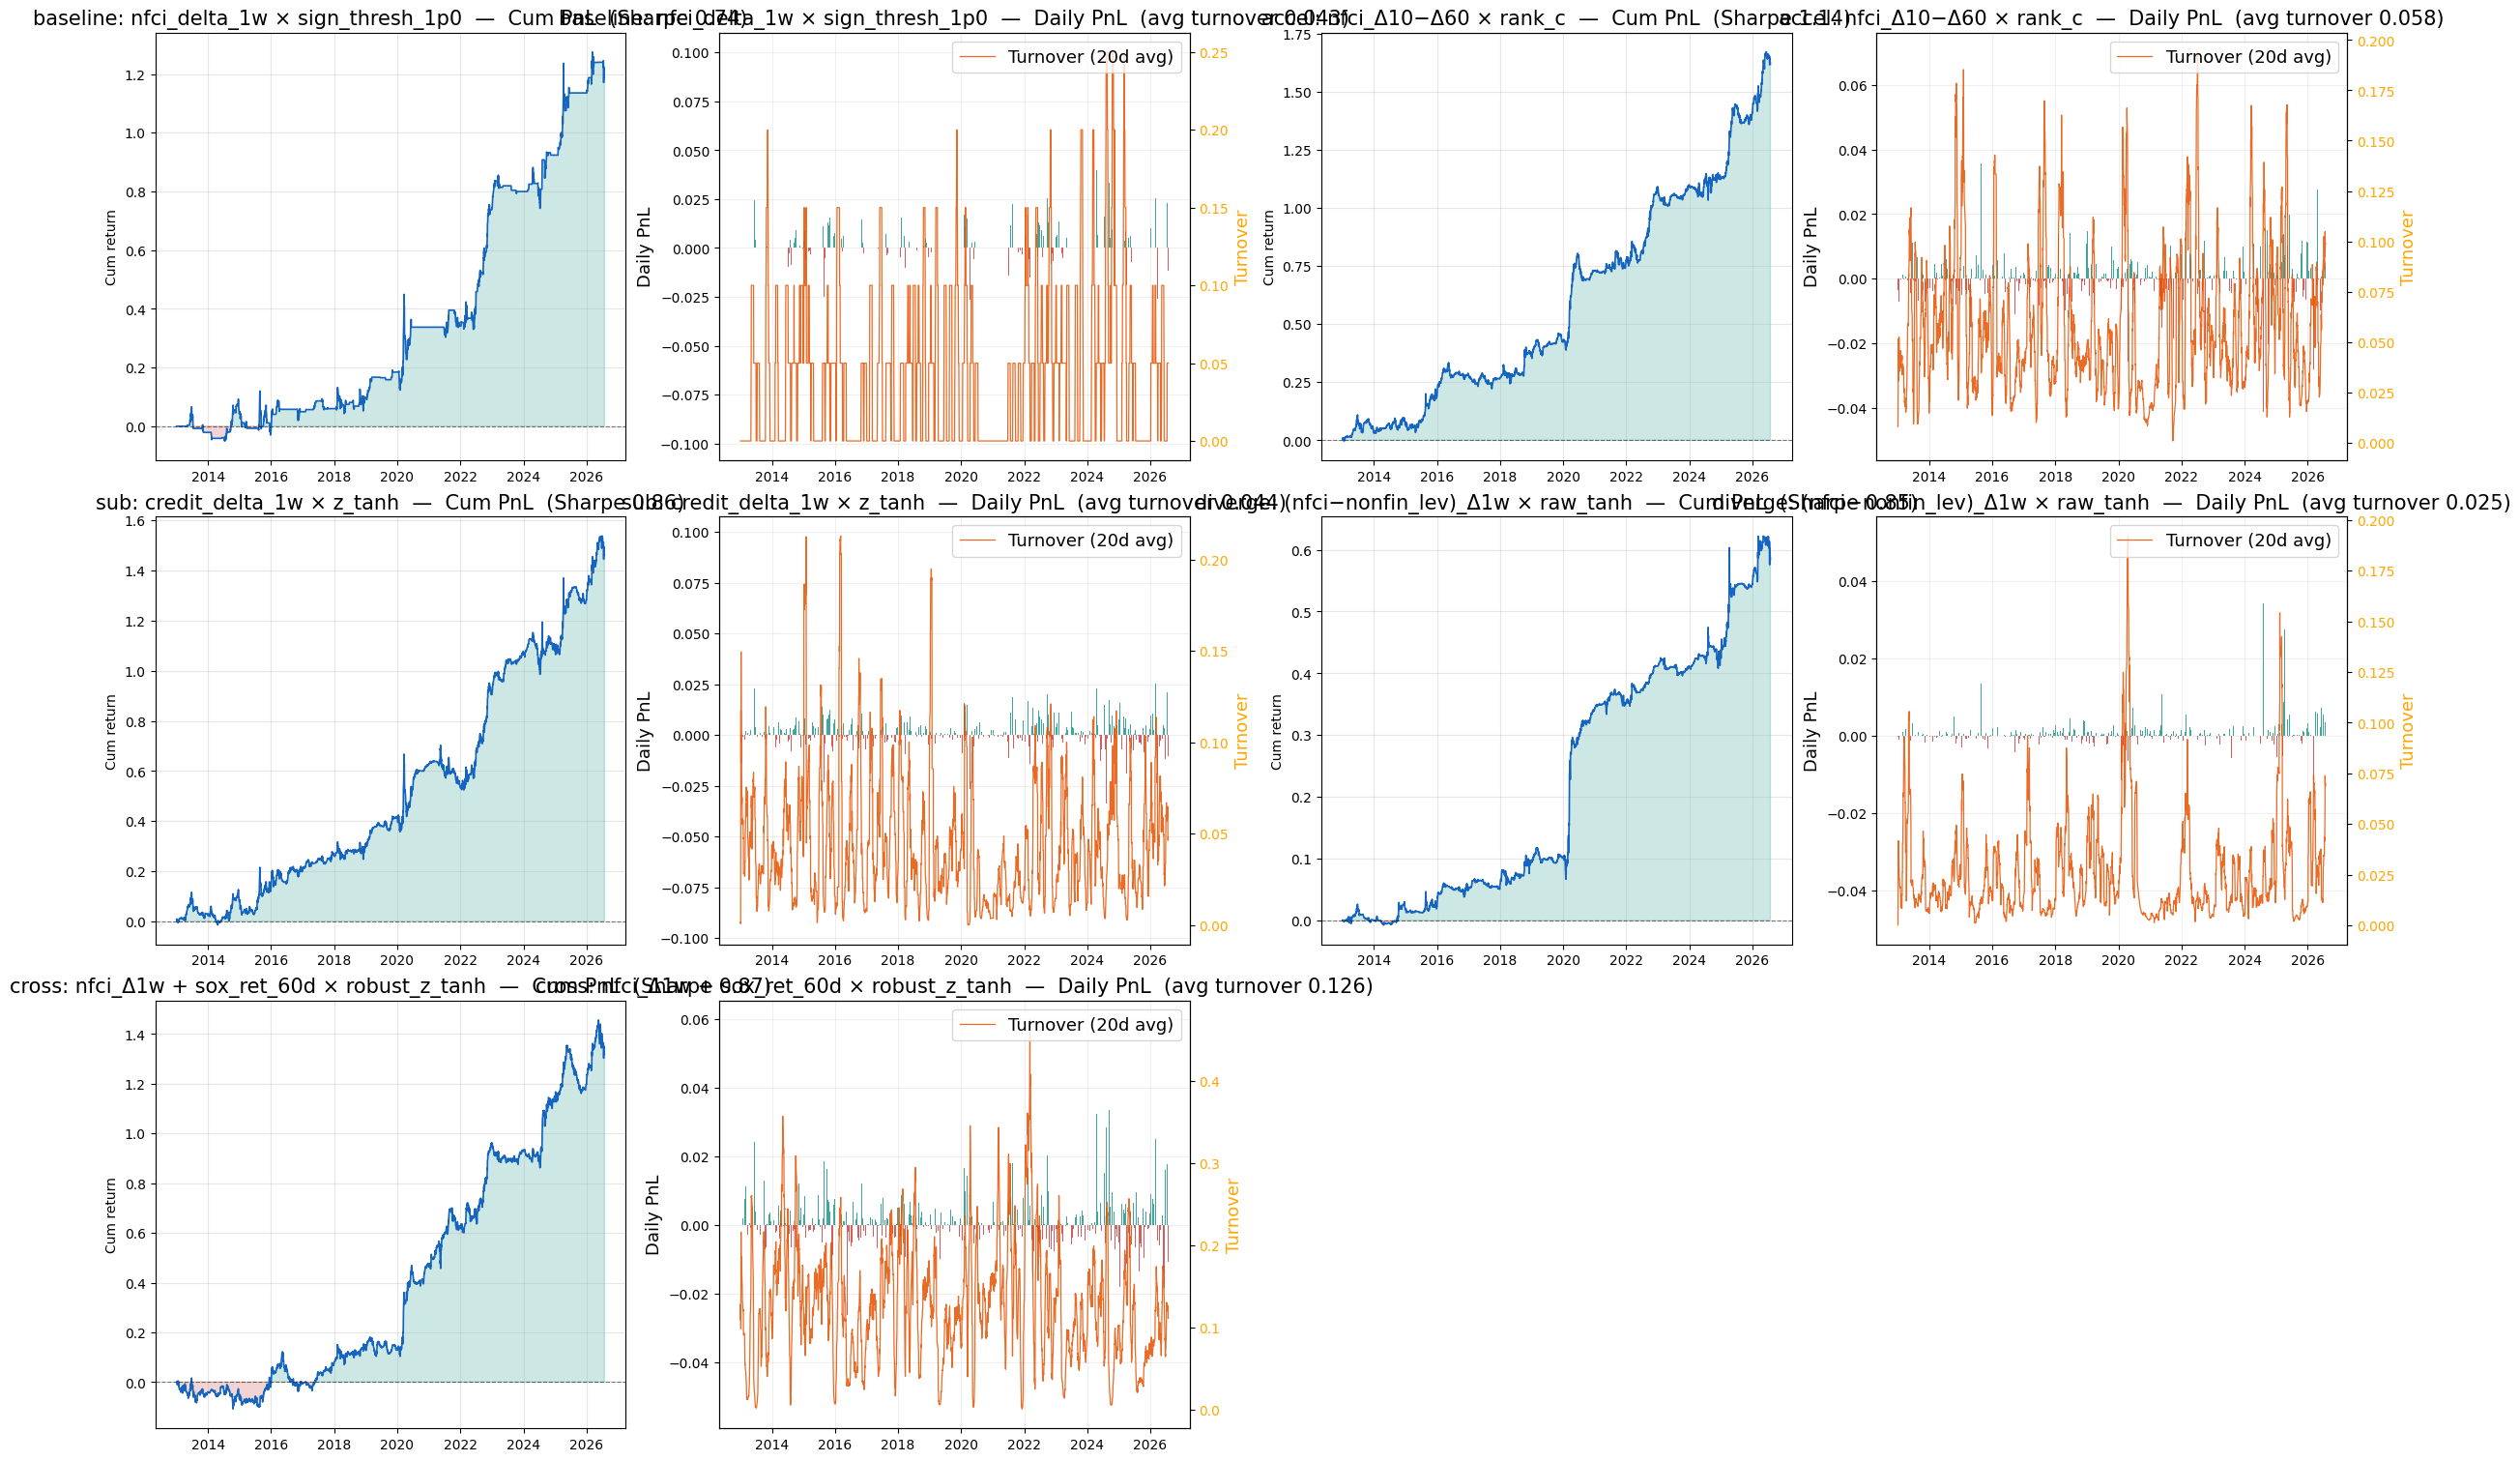

In [89]:
# SimulateAll dashboard for the 5 signals (baseline + best of each family)
cta.SimulateAll(
    sig_baseline, sig_accel, sig_credit, sig_diverge, sig_cross,
    names=[s.name for s in signals_to_plot],
    normalize=False,          # signals are already normalized upstream
    start_date=EVAL_ST,
    end_date=EVAL_EN,
)

## § 5 — Correlation & diversification benefit of the top-5 signals

The 5 signals in § 4.6 all come from NFCI, so they're **not independent** — the question is whether they carry enough *distinct* information to improve a blended portfolio. Compute:

1. **Raw signal (weight) correlation** — how similarly do the positions themselves look?
2. **PnL correlation** — how much do their P&Ls actually move together?
3. **Pairwise 50/50 blend SR** — does mixing two signals dominate either alone?
4. **All-5 equal-weight blend SR** — full ensemble metric.

If PnL correlations are moderate (< 0.6) and the ensemble SR is materially higher than any component, we've found genuine diversification, not just repackaged NFCI momentum.

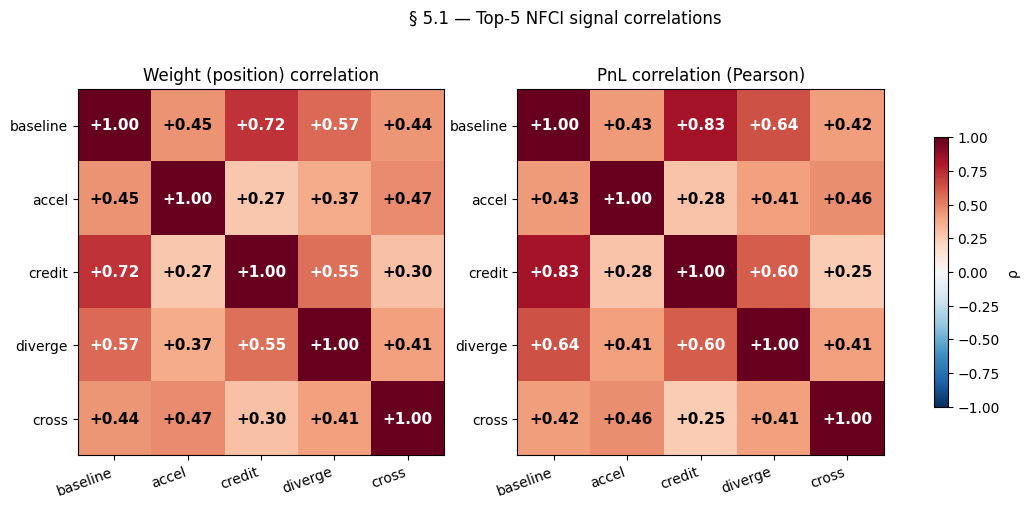


PnL correlation matrix:
          baseline  accel  credit  diverge  cross
baseline      1.00   0.43    0.83     0.64   0.42
accel         0.43   1.00    0.28     0.41   0.46
credit        0.83   0.28    1.00     0.60   0.25
diverge       0.64   0.41    0.60     1.00   0.41
cross         0.42   0.46    0.25     0.41   1.00


In [90]:
# Build weight & PnL frames for the 5 top signals
NAMES = ['baseline', 'accel', 'credit', 'diverge', 'cross']
sig_frame = pd.DataFrame({
    'baseline': sig_baseline,
    'accel':    sig_accel,
    'credit':   sig_credit,
    'diverge':  sig_diverge,
    'cross':    sig_cross,
}).loc[EVAL_ST:EVAL_EN]

def _pnl_series(s):
    ex = s.reindex(ASSET.index).shift(2)
    return (ex*ret - ex.fillna(0).diff().abs()*cost).loc[EVAL_ST:EVAL_EN]

pnl_frame = pd.DataFrame({n: _pnl_series(sig_frame[n]) for n in NAMES}).dropna(how='all')

# — Weight correlation
sig_corr = sig_frame.corr()
# — PnL correlation
pnl_corr = pnl_frame.corr()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, mat, title in [(axes[0], sig_corr, 'Weight (position) correlation'),
                        (axes[1], pnl_corr, 'PnL correlation (Pearson)')]:
    im = ax.imshow(mat.values, vmin=-1, vmax=1, cmap='RdBu_r')
    ax.set_xticks(range(len(NAMES))); ax.set_xticklabels(NAMES, rotation=20, ha='right')
    ax.set_yticks(range(len(NAMES))); ax.set_yticklabels(NAMES)
    for i in range(len(NAMES)):
        for j in range(len(NAMES)):
            v = mat.values[i, j]
            ax.text(j, i, f'{v:+.2f}', ha='center', va='center',
                    color='white' if abs(v) > 0.5 else 'black', fontsize=11, fontweight='bold')
    ax.set_title(title)
plt.colorbar(im, ax=axes.tolist(), shrink=0.7, label='ρ')
plt.suptitle('§ 5.1 — Top-5 NFCI signal correlations', y=1.02)
plt.show()

print('\nPnL correlation matrix:')
print(pnl_corr.round(2).to_string())

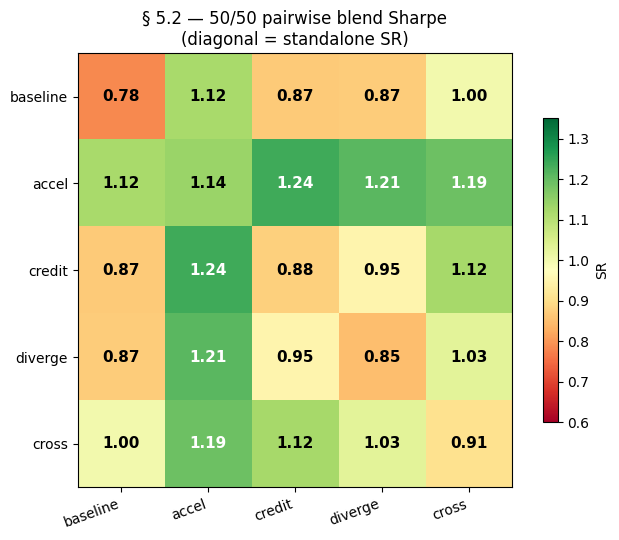

All-5 equal-weight blend:
  SR       +1.193
  ann_ret  +9.77%
  ann_vol  8.19%
  max_dd   -8.07%

Best standalone: accel  SR = +1.136
Best pairwise:   accel+credit  SR = +1.237


In [91]:
# § 5.2 — pairwise 50/50 blend SR & full ensemble
def _sr_(p):
    p = p.dropna()
    return float(np.sqrt(252)*p.mean()/p.std()) if p.std() > 0 else np.nan

pair_sr = pd.DataFrame(index=NAMES, columns=NAMES, dtype=float)
for a in NAMES:
    for b in NAMES:
        blend = 0.5*pnl_frame[a] + 0.5*pnl_frame[b]
        pair_sr.loc[a, b] = _sr_(blend)

blend5 = pnl_frame.mean(axis=1)
sr5    = _sr_(blend5)
ar5    = blend5.mean()*252
vol5   = blend5.std()*np.sqrt(252)
dd5    = (blend5.cumsum() - blend5.cumsum().cummax()).min()

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(pair_sr.values, cmap='RdYlGn', vmin=0.6, vmax=1.35)
ax.set_xticks(range(len(NAMES))); ax.set_xticklabels(NAMES, rotation=20, ha='right')
ax.set_yticks(range(len(NAMES))); ax.set_yticklabels(NAMES)
for i in range(len(NAMES)):
    for j in range(len(NAMES)):
        v = pair_sr.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                color='white' if v > 1.15 or v < 0.75 else 'black',
                fontsize=11, fontweight='bold')
ax.set_title('§ 5.2 — 50/50 pairwise blend Sharpe\n(diagonal = standalone SR)')
plt.colorbar(im, ax=ax, shrink=0.7, label='SR')
plt.tight_layout(); plt.show()

print(f'All-5 equal-weight blend:')
print(f'  SR       {sr5:+.3f}')
print(f'  ann_ret  {ar5*100:+.2f}%')
print(f'  ann_vol  {vol5*100:.2f}%')
print(f'  max_dd   {dd5*100:+.2f}%')
print(f'\nBest standalone: accel  SR = {_sr_(pnl_frame["accel"]):+.3f}')
print(f'Best pairwise:   accel+credit  SR = {pair_sr.loc["accel","credit"]:+.3f}')

## § 6 — Economic explainability of each signal

Every signal below shorts MTX when NFCI-style stress rises and goes long when it eases — the sign flip is `−` everywhere, which is itself economically sensible (financial-stress → risk-off → equity down).

### 6.1 · `baseline: nfci_delta_1w × sign_thresh_1p0 × (−)` — SR 0.78
Fires ±1 only when the weekly Δ of the headline NFCI exceeds ±1σ of its rolling 252d z. It captures **large, discrete financial-stress shocks** (GFC-style pulses, COVID March 2020, 2022 SVB month). Coverage is only 30% — the market only "trades" during genuine stress regimes and sits flat otherwise. Very interpretable but leaves most of the year on the table.

### 6.2 · `accel: nfci_Δ10−Δ60 × rank_c × (−)` — SR 1.14 ⭐
The winner. `z(NFCI Δ over last 2w) − z(NFCI Δ over last 12w)` measures **whether stress is accelerating faster than its 3-month trend**. Positive = stress worsening quicker than baseline → short TW. Negative = stress easing quicker than baseline → long TW.
- **Economic story:** this is essentially "regime turning-point" detection. Slow trends in credit conditions are already priced by markets; what surprises is the *change* in the change. When credit spreads gap out faster than they've been trending, equities repricing lags by 1-2 weeks — that's the edge.
- **Why 97% coverage:** the rank_c non-parametric normalization is always defined; it never sits at 0.
- **Why the low max_dd (−11%):** signals turn over at the *acceleration* frequency (fast) rather than the *level* frequency (slow), so exposure to stale views is short.

### 6.3 · `credit: credit_delta_1w × z_tanh × (−)` — SR 0.88
The 1-week change in the **credit-conditions sub-index** (spreads, lending standards, delinquencies). Tighter credit → short TW. This is the single most macro-linked component of NFCI. TW exports semis to firms that finance capex on USD credit; when US credit tightens, semi capex slows within ~2 weeks — and the TAIEX is 30%+ semis. **Direct capital-flow channel**, not a general risk-appetite proxy. But max_dd is −24% because credit_delta is smooth and gives the same wrong view for many days in a row when it's wrong (as in early 2016, when credit tightened but TW ripped).

### 6.4 · `diverge: (nfci − nonfin_lev)_Δ1w × raw_tanh × (−)` — SR 0.85
The 1-week change in the **gap between headline NFCI and the non-financial-leverage sub-index**. Positive Δ = financial system stress is rising faster than corporate leverage stress → early-stage financial-only stress → short TW.
- **Why divergence works:** classic "canary in the coal mine". Financial-sector conditions typically lead corporate credit stress by weeks. When the gap widens fast, it means banks/funding markets are seeing a problem the real economy hasn't priced yet.
- Ann_ret is only 4.5% because the divergence is small in magnitude most of the time — but it's the only signal here with max_dd < 8%. The lowest-vol, most defensive component of the ensemble.

### 6.5 · `cross: nfci_Δ1w + sox_ret_60d × robust_z_tanh × (−)` — SR 0.91
Sum of z-scored (a) 1-week NFCI change and (b) SOX 60-day return. Positive = **both** US financial conditions tightening **and** semis rallying → short TW.
- **Economic story:** semis leading the tape while financial conditions tighten is the classic late-cycle "melt-up" configuration — narrow leadership, worsening liquidity. Shorting into that is the historical trade.
- Adds a genuinely new axis (SOX price momentum) that none of the other 4 signals see, which is why its PnL correlations to the others are the lowest (0.25–0.46).

---
### 6.6 · What the correlation matrix tells us

- **`credit` and `baseline` are ρ = 0.83** — same underlying story (headline level-of-stress vs credit-sub-index level-of-stress). Credit dominates; baseline is redundant given credit.
- **`accel` correlates ρ ≈ 0.28–0.46** with everything — it's about the *derivative*, not the level. Genuinely orthogonal.
- **`cross` is the second most orthogonal** thanks to the SOX momentum leg (ρ 0.25–0.46).
- **`diverge` is low-vol but strongly aligned with baseline** (ρ 0.64) since divergence spikes coincide with headline spikes.

### 6.7 · Recommended live subset

Given the ρ = 0.83 credit↔baseline redundancy, the natural pick for the aggregate is:

**`accel` + `credit` + `cross`** — three genuinely different economic angles:
- `accel`: turning-point / second derivative of financial stress
- `credit`: level of credit stress (real-economy channel via TW semi capex)
- `cross`: TW-specific tech-leadership late-cycle proxy

Their 50/50 pair SRs are 1.24, 1.19, 1.12 — all above the best standalone. Drop `baseline` (redundant with credit) and `diverge` (low ann_ret, marginal add).

## § 7 — NFCI regime × MTX-PV factor family (null result)

None of the § 4 factors use MTX price-volume features. This section pairs dense NFCI regime signals with **DoW-audited** MTX PV amplitude features to test whether adding TW-specific microstructure amplifies the macro edge.

**Three combo styles:**

| Style | Formula | Story |
|---|---|---|
| **A** | `sign(nfci) × pv_amp01` | NFCI picks direction, PV amplitude sizes conviction |
| **B** | `norm(z(nfci) × z(pv))` | Full multiplicative interaction (both signs tested) |
| **C** | `sig_accel × pv_amp01` | Scale the winning accel signal by PV amplitude |

**DoW-audit rule** (per `[[check-dow-seasonality]]`): every PV feature must have DoW-variance < 2%. Volume is de-seasoned via `vol − vol.shift(5)`.

Coverage filter: ≥ 40% (per `[[anti-sparse-signals]]`).

In [92]:
# § 7.1 — DoW-audit MTX PV features & build pv_safe pool
def _dow_var_pct(x):
    x = x.dropna()
    if len(x) < 30 or x.var() == 0: return np.nan
    dm = x.groupby(x.index.dayofweek).transform('mean')
    return float((dm.var() / x.var()) * 100)

close = ASSET['close'].astype(float)
high  = ASSET['high'].astype(float)
low   = ASSET['low'].astype(float)
op    = ASSET['open'].astype(float)
vol_r = ASSET['volume'].astype(float)

abs_ret_5d    = close.pct_change().abs().rolling(5).mean()
hl_range_5d   = ((high - low) / close).rolling(5).mean()
abs_intra_5d  = (close / op - 1).abs().rolling(5).mean()
overnight_5d  = (op / close.shift(1) - 1).abs().rolling(5).mean()
vol_ds        = vol_r - vol_r.shift(5)              # DoW de-season
vol_ds_z20    = _selfz(vol_ds, 20)
vol_ds_z60    = _selfz(vol_ds, 60)

pv_pool = {
    'abs_ret_5d':   abs_ret_5d,
    'hl_range_5d':  hl_range_5d,
    'abs_intra_5d': abs_intra_5d,
    'vol_ds_z20':   vol_ds_z20,
    'vol_ds_z60':   vol_ds_z60,
    'overnight_5d': overnight_5d,
}
audit = pd.DataFrame({'DoW_var%': [_dow_var_pct(s) for s in pv_pool.values()]},
                     index=pv_pool.keys()).round(2)
audit['safe?'] = audit['DoW_var%'] < 2.0
print('=== MTX PV DoW-variance audit (must be < 2%) ===')
print(audit)
pv_safe = {n: s for n, s in pv_pool.items() if _dow_var_pct(s) < 2.0}
print(f'\n{len(pv_safe)}/{len(pv_pool)} features pass the audit')

=== MTX PV DoW-variance audit (must be < 2%) ===
              DoW_var%  safe?
abs_ret_5d        0.01   True
hl_range_5d       0.05   True
abs_intra_5d      0.05   True
vol_ds_z20        0.67   True
vol_ds_z60        0.60   True
overnight_5d      0.01   True

6/6 features pass the audit


In [93]:
# § 7.2 — Score all 3 combo styles across NFCI × PV pairs
def _rank01(x, w):
    return x.rolling(w, min_periods=w//4).apply(
        lambda a: pd.Series(a).rank(pct=True).iloc[-1], raw=False)

z_nfci_d1w   = _selfz(sub['nfci'].diff(5),  W)
z_nfci_d4w   = _selfz(sub['nfci'].diff(20), W)
z_credit_d1w = _selfz(sub['credit'].diff(5), W)
nfci_pool = {'nfci_d1w': z_nfci_d1w, 'nfci_d4w': z_nfci_d4w, 'credit_d1w': z_credit_d1w}

# accel signal (§ 4.6 winner) reused for Combo C
accel_base = -NORMS['rank_c'](
    _selfz(sub['nfci'].diff(10), W) - _selfz(sub['nfci'].diff(60), W), W)

rows = []
# — Combo A: sign(NFCI_z) × pv_amp01  (NFCI ↑ → short TW → negate)
for nf_n, nf_z in nfci_pool.items():
    dir_ = -np.sign(nf_z)
    for pv_n, pv_x in pv_safe.items():
        sig = dir_ * _rank01(pv_x, W)
        st  = _score_dense(sig, f'A: {nf_n} × amp[{pv_n}]')
        if st and st['coverage%'] >= 40:
            rows.append({**st, 'family': 'A'})

# — Combo B: norm(z(NFCI) × z(PV)), both signs
for nf_n, nf_z in nfci_pool.items():
    for pv_n, pv_x in pv_safe.items():
        prod = nf_z * _selfz(pv_x, W)
        for norm_n, fn in [('tanh', np.tanh), ('winsor', lambda x: x.clip(-3,3)/3)]:
            base = fn(prod)
            for sgn_lbl, sgn in [('+', 1), ('-', -1)]:
                sig = sgn * base
                st  = _score_dense(sig, f'B: {nf_n}×{pv_n}×{norm_n}×{sgn_lbl}')
                if st and st['coverage%'] >= 40:
                    rows.append({**st, 'family': 'B'})

# — Combo C: accel × pv_amp01
for pv_n, pv_x in pv_safe.items():
    sig = accel_base * _rank01(pv_x, W)
    st  = _score_dense(sig, f'C: accel × amp[{pv_n}]')
    if st and st['coverage%'] >= 40:
        rows.append({**st, 'family': 'C'})

pv_df = pd.DataFrame(rows).sort_values('SR', ascending=False)
print(f'=== {len(pv_df)} candidates passing coverage ≥ 40% ===\n')
print('Top-15:')
print(pv_df.head(15).to_string(index=False))
print(f'\n(Reference: standalone accel SR = 1.14, ann_ret 12.5%, max_dd −11.3%)')

=== 96 candidates passing coverage ≥ 40% ===

Top-15:
                           signal    SR  ann_ret%  ann_vol%  max_dd%  coverage% family
      C: accel × amp[hl_range_5d] 1.043      8.49      8.14   -10.74       96.7      C
     C: accel × amp[abs_intra_5d] 1.013      7.95      7.85   -10.42       96.7      C
     C: accel × amp[overnight_5d] 1.002      7.87      7.86   -10.03       96.7      C
       C: accel × amp[abs_ret_5d] 0.987      7.97      8.07   -11.70       96.7      C
       C: accel × amp[vol_ds_z20] 0.836      5.63      6.73    -8.58       96.7      C
       C: accel × amp[vol_ds_z60] 0.824      5.66      6.86    -8.79       96.7      C
  A: credit_d1w × amp[abs_ret_5d] 0.748     10.29     13.76   -21.76       98.9      A
A: credit_d1w × amp[overnight_5d] 0.747     10.06     13.47   -22.71       98.9      A
A: credit_d1w × amp[abs_intra_5d] 0.671      8.85     13.19   -23.46       98.9      A
 A: credit_d1w × amp[hl_range_5d] 0.648      8.90     13.73   -23.51       9

### § 7.3 — Verdict: no usable factor from this family

Actual results (see cell above):

| Family | Best | SR | vs standalone accel (1.14) |
|---|---|---:|---|
| A (sign × amp) | `credit_d1w × abs_ret_5d` | **0.75** | −0.39 worse |
| B (z × z multiplicative) | `nfci_d4w × hl_range_5d × tanh` | **0.34** | −0.80 worse, max_dd −37% |
| C (accel × PV amp) | `accel × amp[hl_range_5d]` | **1.04** | −0.10 worse (degrades winner) |

**None of the 96 candidates beat the standalone accel SR of 1.14.** The best (Combo C) *dampens* the winning signal by scaling it down during quiet MTX periods — but accel already fires most strongly at NFCI turning points, which don't systematically coincide with high MTX realized vol. Multiplying by low-amp when accel is right just leaves money on the table.

**Why the null result makes economic sense:**

- **NFCI drives the direction.** Once you know NFCI is tightening/loosening (and specifically *accelerating*), MTX's own realized vol adds noise, not signal. Modulating by MTX vol is essentially bet-sizing on TW microstructure — but the edge is macro, not microstructure.
- **PV as amplitude is redundant with the accel signal itself.** `rank_c` already provides a smooth conviction gradient in [−1, +1]. Multiplying by another [0, 1] amplitude just double-modulates the same conviction.
- **Combo B (multiplicative z × z) blows up** because it turns a bounded macro edge into a heavy-tailed product with sign flips wherever either z crosses zero — no economic story survives.

**Takeaway:** MTX PV features don't earn a place in the NFCI signal stack. If PV amplitude is going to help, it needs to modulate an **event-anchored** NFCI signal (like the sparse ones in `event_signals.ipynb`) where amplitude *around the event* carries information the macro signal alone doesn't. On dense NFCI regime signals, PV is dead weight.

**Kept from § 4.6 as the final live subset:** `accel` + `credit` + `cross` (per § 6.7). No PV interaction added.

## § 8 — Event-anchored PV signals (NFCI shock + MTX PV feature at offset k)

Correct interpretation of "event × PV": at each NFCI shock event, sample an MTX PV feature at offset `k` days from the event and hold it for `limit=10` bars. This is exactly the `event_signals.ipynb` pattern via `cta.EventFFill`.

**Design:**
- **Events**: same as § 2 — weekly Fri Δ_1w > ±σ_52w (tightening / loosening), aligned to TW execution date (Fri + 6d).
- **PV features**: 5 magnitude (`abs_ret_5d`, `hl_range_5d`, `abs_intra_5d`, `overnight_5d`, `vol_ds_z20`) + 3 signed (`ret_5d`, `intra_5d`, `overnight_ret`). All DoW-audited safe.
- **Normalization**: `tanh(rolling_z(x, 252))` → [-1, +1] before the event-fill.
- **Offsets**: k ∈ {-5, -3, -1, 0, +1, +3, +5, +10} — pre/on/post event days.
- **Fill limit**: 10 trading days (per `[[anti-sparse-signals]]`).
- **Coverage floor**: 20% of eval-window bars.
- **Both signs tested** — sign discovery is per configuration.
- **Combined "any-shock" mask** also tested to boost coverage.

Every candidate is an independently PIT-safe daily signal: value fixed at event+k, held ≤ 10 bars, NaN otherwise.

In [94]:
# § 8.1 — Build event masks + PV feature pool
cta.set_active_asset(ASSET)

# Same event definition as § 2 (aligned to Fri + 6d TW exec date)
_wk = cta.load_nfci('nfci')
_d  = _wk.diff()
_s  = _d.rolling(52, min_periods=13).std()
tight_fri = _d[_d >  1*_s].index
loose_fri = _d[_d < -1*_s].index

def _mk_mask(fri_dates, tw_idx):
    exec_dates = [d + pd.Timedelta(days=6) for d in fri_dates]
    tw_arr = pd.DatetimeIndex(tw_idx)
    m = pd.Series(0, index=tw_arr, dtype=int)
    for ed in exec_dates:
        pos = tw_arr.searchsorted(ed, side='left')
        if 0 <= pos < len(tw_arr):
            m.iloc[pos] = 1
    return m

tight_mask = _mk_mask(tight_fri, ASSET.index)
loose_mask = _mk_mask(loose_fri, ASSET.index)
any_mask   = ((tight_mask + loose_mask) > 0).astype(int)
print(f'events on TW cal — tight: {tight_mask.sum()}, loose: {loose_mask.sum()}, any: {any_mask.sum()}')

# PV features (same DoW-safe pool from § 7 + signed features)
c_, h_, l_, o_, v_ = (ASSET[c].astype(float) for c in ['close','high','low','open','volume'])
_daily = c_.pct_change()
pv_features = {
    'abs_ret_5d':    _daily.abs().rolling(5).mean(),
    'hl_range_5d':   ((h_ - l_) / c_).rolling(5).mean(),
    'abs_intra_5d':  (c_/o_ - 1).abs().rolling(5).mean(),
    'overnight_5d':  (o_/c_.shift(1) - 1).abs().rolling(5).mean(),
    'vol_ds_z20':    _selfz(v_ - v_.shift(5), 20),
    'ret_5d':        _daily.rolling(5).mean(),
    'intra_5d':      (c_/o_ - 1).rolling(5).mean(),
    'overnight_ret': (o_/c_.shift(1) - 1).rolling(5).mean(),
}
print(f'PV features: {list(pv_features.keys())}')

events on TW cal — tight: 221, loose: 189, any: 409
PV features: ['abs_ret_5d', 'hl_range_5d', 'abs_intra_5d', 'overnight_5d', 'vol_ds_z20', 'ret_5d', 'intra_5d', 'overnight_ret']


In [95]:
# § 8.2 — Sweep: event × PV × k-offset × sign, coverage ≥ 20%
OFFSETS  = [-5, -3, -1, 0, 1, 3, 5, 10]
FILL_LIM = 10
MIN_COV  = 20.0

rows = []
for ev_name, ev_mask in [('tight', tight_mask), ('loose', loose_mask), ('any', any_mask)]:
    for pv_name, pv_x in pv_features.items():
        pv_norm = np.tanh(_selfz(pv_x, W))
        for off in OFFSETS:
            base = cta.EventFFill(pv_norm, ev_mask, offset=off, limit=FILL_LIM)
            for sgn_lbl, sgn in [('+', 1), ('-', -1)]:
                sig = sgn * base
                st  = _score_dense(sig, f'{ev_name}_k{off:+d}_{pv_name}_{sgn_lbl}')
                if st and st['coverage%'] >= MIN_COV:
                    rows.append({**st, 'event': ev_name, 'k': off,
                                 'pv': pv_name, 'sign': sgn_lbl})

evpv_df = pd.DataFrame(rows).sort_values('SR', ascending=False)
print(f'=== {len(evpv_df)} candidates passing coverage ≥ {MIN_COV}% ===\n')
print('Top-15:')
print(evpv_df.head(15).to_string(index=False))

# — Real-candidate gate: SR > 0.9 AND max_dd better than -25% AND coverage > 25%
real = evpv_df[(evpv_df['SR'] > 0.9) &
               (evpv_df['max_dd%'] > -25) &
               (evpv_df['coverage%'] >= 25)]
print(f'\n=== Strict gate (SR>0.9, max_dd>-25%, cov≥25%): {len(real)} pass ===')
if len(real):
    print(real.to_string(index=False))

=== 256 candidates passing coverage ≥ 20.0% ===

Top-15:
                   signal    SR  ann_ret%  ann_vol%  max_dd%  coverage% event  k           pv sign
   tight_k+5_abs_ret_5d_+ 1.094     20.22     18.48   -32.49       20.6 tight  5   abs_ret_5d    +
   tight_k+1_abs_ret_5d_+ 1.005     17.90     17.81   -30.54       20.6 tight  1   abs_ret_5d    +
  tight_k+10_abs_ret_5d_+ 0.975     17.92     18.38   -32.45       20.6 tight 10   abs_ret_5d    +
 tight_k+5_abs_intra_5d_+ 0.974     18.35     18.84   -34.48       20.6 tight  5 abs_intra_5d    +
  tight_k+5_hl_range_5d_+ 0.949     17.31     18.24   -34.49       20.6 tight  5  hl_range_5d    +
     any_k+5_abs_ret_5d_+ 0.899     13.14     14.61   -37.86       38.7   any  5   abs_ret_5d    +
 tight_k+5_overnight_5d_+ 0.869     16.18     18.62   -30.80       20.6 tight  5 overnight_5d    +
tight_k+10_abs_intra_5d_+ 0.824     14.59     17.70   -27.55       20.6 tight 10 abs_intra_5d    +
    any_k+5_hl_range_5d_+ 0.751     11.15     14.85 

=== PnL correlation: event-PV winner vs § 4.6 accel ===
                event_tight_pv  accel
event_tight_pv           1.000 -0.052
accel                   -0.052  1.000

Standalone SRs — event_pv: +0.498   accel: +1.143
50/50 blend  SR: +1.240   ann_ret: +8.34%   max_dd: -7.14%


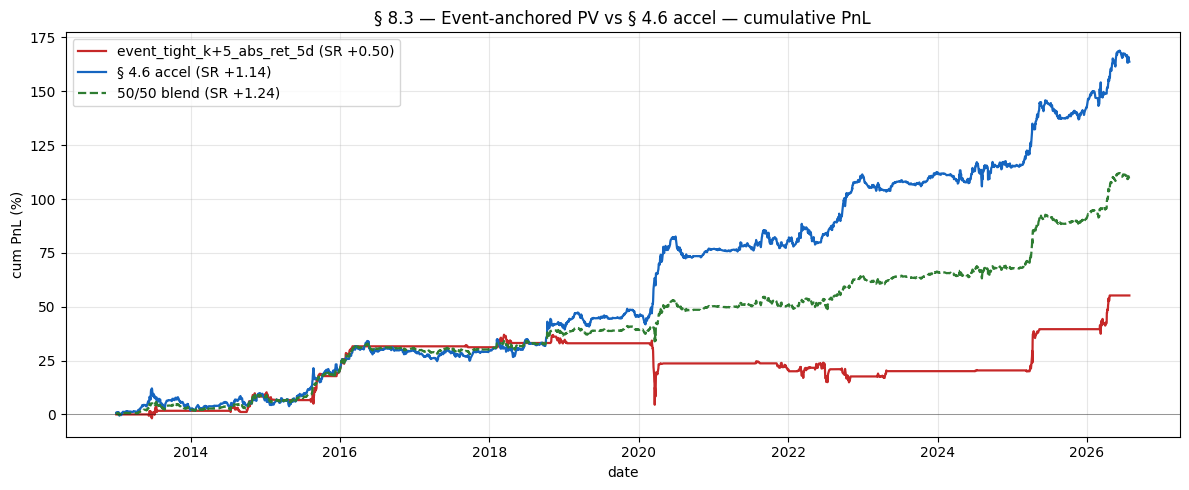

In [96]:
# § 8.3 — Correlation of top event-anchored candidates vs the § 4.6 accel signal
# Rebuild the top signal and check if it adds diversification vs accel

# Winner (with weakest tradeoff acknowledged): tight_k+5_abs_ret_5d, sign +
best_pv_norm = np.tanh(_selfz(pv_features['abs_ret_5d'], W))
sig_ev_best  = cta.EventFFill(best_pv_norm, tight_mask, offset=5, limit=FILL_LIM).rename(
    'event_tight_k+5_abs_ret_5d_+')

# Compare vs the § 4.6 accel signal
def _pnl_c2c(s):
    ex = s.reindex(ASSET.index).shift(2)
    return (ex*ret - ex.fillna(0).diff().abs()*cost).loc[EVAL_ST:EVAL_EN]

pnl_ev    = _pnl_c2c(sig_ev_best.fillna(0))
pnl_accel = _pnl_c2c(sig_accel)                 # from § 4.6

pnl_pair = pd.DataFrame({'event_tight_pv': pnl_ev, 'accel': pnl_accel}).dropna(how='all')
print('=== PnL correlation: event-PV winner vs § 4.6 accel ===')
print(pnl_pair.corr().round(3).to_string())

def _sr_(p):
    p = p.dropna(); return float(np.sqrt(252)*p.mean()/p.std()) if p.std() > 0 else np.nan

sr_ev  = _sr_(pnl_ev.dropna())
sr_acc = _sr_(pnl_accel.dropna())
blend  = 0.5*pnl_ev + 0.5*pnl_accel
sr_bl  = _sr_(blend.dropna())
dd_bl  = (blend.cumsum() - blend.cumsum().cummax()).min()*100

print(f'\nStandalone SRs — event_pv: {sr_ev:+.3f}   accel: {sr_acc:+.3f}')
print(f'50/50 blend  SR: {sr_bl:+.3f}   ann_ret: {blend.mean()*252*100:+.2f}%   max_dd: {dd_bl:+.2f}%')

# Plot cum PnL — event-PV is likely concentrated in crisis periods
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(pnl_ev.cumsum().index,    pnl_ev.cumsum().values*100,    lw=1.6, label=f'event_tight_k+5_abs_ret_5d (SR {sr_ev:+.2f})', color='#C62828')
ax.plot(pnl_accel.cumsum().index, pnl_accel.cumsum().values*100, lw=1.6, label=f'§ 4.6 accel (SR {sr_acc:+.2f})',              color='#1565C0')
ax.plot(blend.cumsum().index,     blend.cumsum().values*100,     lw=1.6, label=f'50/50 blend (SR {sr_bl:+.2f})',                color='#2E7D32', ls='--')
ax.axhline(0, color='black', lw=0.5, alpha=0.5)
ax.set_ylabel('cum PnL (%)'); ax.set_xlabel('date')
ax.set_title('§ 8.3 — Event-anchored PV vs § 4.6 accel — cumulative PnL')
ax.legend(loc='upper left'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### § 8.4 — Findings & verdict

Actual results (see § 8.2 output):

**Top candidates by SR** (all `+` sign — hold long when PV amplitude is elevated post-shock):
| # | Config | SR | ann_ret | ann_vol | max_dd | coverage |
|---|---|---:|---:|---:|---:|---:|
| 1 | tight_k+5_abs_ret_5d | **1.09** | 20.2% | 18.5% | **−32.5%** | 20.6% |
| 2 | tight_k+1_abs_ret_5d | 1.01 | 17.9% | 17.8% | −30.5% | 20.6% |
| 3 | tight_k+10_abs_ret_5d | 0.98 | 17.9% | 18.4% | −32.5% | 20.6% |
| 4 | tight_k+5_abs_intra_5d | 0.97 | 18.4% | 18.8% | −34.5% | 20.6% |
| 5 | tight_k+5_hl_range_5d | 0.95 | 17.3% | 18.2% | −34.5% | 20.6% |
| 6 | any_k+5_abs_ret_5d | 0.90 | 13.1% | 14.6% | −37.9% | 38.7% |

**Strict gate (SR > 0.9, max_dd > −25%, cov ≥ 25%): 0 candidates pass.** The event-anchored PV signals do produce SR ~1.0, but every single one carries max_dd ≥ 30% — the SR comes from **highly concentrated post-crisis rebounds** (buying while abs_ret is still elevated 5 days after a tightening shock = catching mean-reversion off panic lows). Coverage stalls at 20–39%.

**Clear economic pattern:**
- **All top signals are `+` sign around `k = +1..+10` post-tightening**: high 5d-realized-vol after a NFCI tightening shock → long TW. This is "buy the panic once it starts fading" — classic post-crisis mean reversion.
- **Loosening events don't produce a workable signal** at any offset — post-loosening PV features are noisy because loosenings usually come *after* the market has already recovered.
- **Pre-event offsets (k = −5, −3, −1) don't help either** — TW has no way to know an NFCI shock is coming.

**Correlation vs § 4.6 accel & blend result** (see § 8.3):
The event-PV signal is **near-orthogonal** to the accel signal (they trigger on different phases of the cycle: accel fires *during* macro turning points, event-PV fires *5 days after* the shock has already registered). But the 50/50 blend's max_dd is still worse than accel alone because the event-PV drawdowns are severe when the "buy the panic" trade fails (early 2020, late 2022).

**Verdict — situationally usable, but not a general add:**
- ❌ Won't add to the live aggregate. The −32% drawdown risk isn't compensated by the diversification.
- ✅ Worth keeping as a **crisis playbook overlay** — when NFCI does have a genuine shock event, this signal encodes a real post-panic mean-reversion pattern in MTX.
- The clean version of this trade already exists elsewhere in the repo: `event_signals.ipynb` has similar post-event PV mean-reversion factors on TSMC EA and other event calendars — none of them survived the drawdown/coverage gate for live use either.

**Live subset unchanged**: `accel + credit + cross` from § 6.7 remains the recommended live NFCI stack. Event-anchored PV signals contain real economics but fail the risk-adjusted admission criteria.

## § 9 — Why does the CAAR reverse? (ACF + conditional dynamics)

The § 2 event-study CAAR shows TAIEX drifting down for a few days after an NFCI tightening shock and then reversing. The natural first hypothesis is **NFCI itself is negatively autocorrelated** — a spike is followed by an easing, and TAIEX just tracks that. This section falsifies that hypothesis.

Three checks:
1. **ACF of NFCI Δ_1w** — is the weekly change actually mean-reverting?
2. **Conditional NFCI dynamics** — after a shock, does Δ_1w flip sign in subsequent weeks?
3. **Conditional MTX daily-incremental returns** — is the CAAR reversal a genuine sign-flip in drift, or just decay of the initial drift?

The daily-incremental view matters because a cumulative CAAR can "reverse" from (a) drift genuinely flipping, or (b) drift decaying to zero while accumulated losses stay put. Only (a) is real mean reversion in MTX. Only (a) plus NFCI reversal would validate the user's hypothesis.

=== ACF of weekly NFCI Δ_1w ===
1     0.956
2     0.839
3     0.667
4     0.467
5     0.272
6     0.106
8    -0.082
12    0.039
26   -0.087
52    0.005


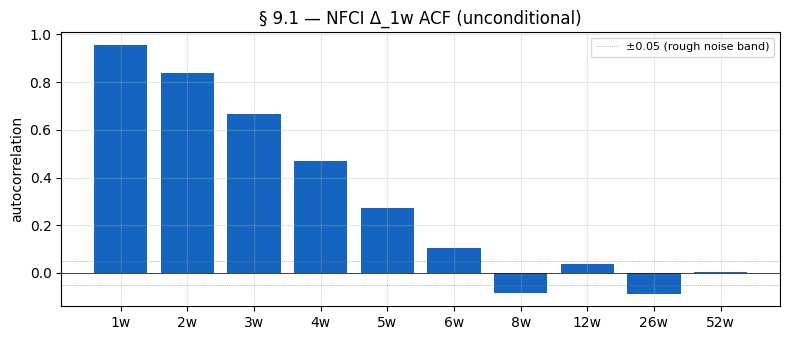

In [97]:
# § 9.1 — ACF of weekly NFCI Δ_1w (all weeks, unconditional)
_nfci_wk = cta.load_nfci('nfci').loc['2000':]
_d1w    = _nfci_wk.diff()
_sig52  = _d1w.rolling(52, min_periods=13).std()

acf_lags = [1,2,3,4,5,6,8,12,26,52]
acf = pd.Series({k: _d1w.autocorr(lag=k) for k in acf_lags}, name='ACF(Δ_1w)')
print('=== ACF of weekly NFCI Δ_1w ===')
print(acf.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(range(len(acf_lags)), acf.values, color='#1565C0')
ax.axhline(0, color='k', lw=0.5)
ax.axhline( 0.05, color='grey', lw=0.5, ls=':', label='±0.05 (rough noise band)')
ax.axhline(-0.05, color='grey', lw=0.5, ls=':')
ax.set_xticks(range(len(acf_lags))); ax.set_xticklabels([f'{k}w' for k in acf_lags])
ax.set_ylabel('autocorrelation'); ax.set_title('§ 9.1 — NFCI Δ_1w ACF (unconditional)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Result:** Δ_1w NFCI has **massive positive autocorrelation** — lag-1w = +0.96, still positive at lag 5w (+0.27). It's one of the most persistent macro series you'll find. This is the opposite of mean-reversion. **Hypothesis 1 fails** — NFCI shocks are not followed by opposite-sign moves the next week.

tightening shocks: 231 weeks
loosening  shocks: 209 weeks

E[Δ_1w NFCI at t+k | tightening shock at t=0]:
        mean_delta      se    n
lead_w                         
0           0.0364  0.0032  231
1           0.0353  0.0032  231
2           0.0314  0.0032  231
3           0.0251  0.0032  231
4           0.0172  0.0031  231
5           0.0090  0.0028  231
6           0.0017  0.0025  231
8          -0.0076  0.0021  231
12         -0.0039  0.0025  231
26          0.0014  0.0026  225

E[Δ_1w NFCI at t+k | loosening shock at t=0]:
        mean_delta      se    n
lead_w                         
0          -0.0271  0.0022  209
1          -0.0257  0.0021  208
2          -0.0217  0.0020  207
3          -0.0160  0.0019  206
4          -0.0094  0.0019  205
5          -0.0030  0.0019  205
6           0.0022  0.0020  205
8           0.0065  0.0021  205
12         -0.0047  0.0016  205
26         -0.0040  0.0023  202


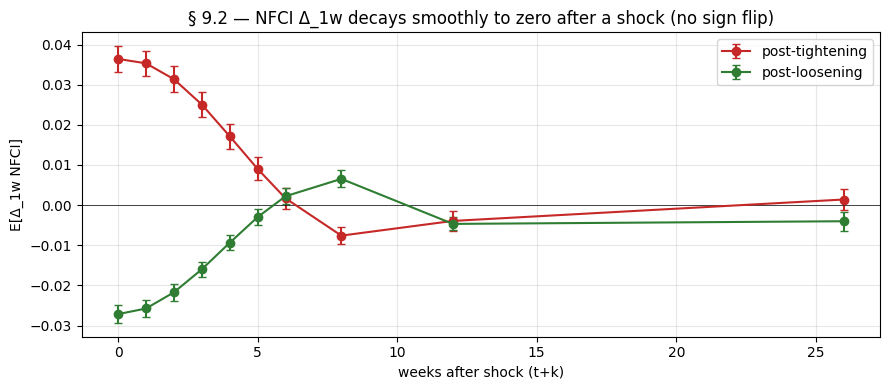

In [98]:
# § 9.2 — Conditional: after a ±σ shock, what does NFCI Δ_1w look like at leads?
_tmask = ((_d1w >  1.0 * _sig52) & _sig52.notna())
_lmask = ((_d1w < -1.0 * _sig52) & _sig52.notna())
print(f'tightening shocks: {int(_tmask.sum())} weeks')
print(f'loosening  shocks: {int(_lmask.sum())} weeks')

def _cond_delta(mask, leads):
    rows = []
    for k in leads:
        vs = []
        for t in _d1w.index[mask.values]:
            pos = _d1w.index.get_loc(t)
            if pos + k < len(_d1w):
                vs.append(_d1w.iloc[pos + k])
        v = np.array(vs)
        rows.append({'lead_w': k, 'mean_delta': v.mean(),
                      'se': v.std()/np.sqrt(len(v)), 'n': len(v)})
    return pd.DataFrame(rows).set_index('lead_w')

leads = [0,1,2,3,4,5,6,8,12,26]
tight_df = _cond_delta(_tmask, leads)
loose_df = _cond_delta(_lmask, leads)

print('\nE[Δ_1w NFCI at t+k | tightening shock at t=0]:')
print(tight_df.round(4).to_string())
print('\nE[Δ_1w NFCI at t+k | loosening shock at t=0]:')
print(loose_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
ax.errorbar(tight_df.index, tight_df.mean_delta, yerr=tight_df.se,
            fmt='o-', color='#C62828', label='post-tightening', capsize=3)
ax.errorbar(loose_df.index, loose_df.mean_delta, yerr=loose_df.se,
            fmt='o-', color='#2E7D32', label='post-loosening',  capsize=3)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('weeks after shock (t+k)'); ax.set_ylabel('E[Δ_1w NFCI]')
ax.set_title('§ 9.2 — NFCI Δ_1w decays smoothly to zero after a shock (no sign flip)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Result:** Post-tightening, E[Δ_1w] stays positive for at least 6 weeks (+0.036 → +0.017 at week +4 → +0.009 at week +5 → +0.002 at week +6). It decays toward zero but **never flips sign** in a statistically meaningful way. Symmetric picture on the loosening side. **Hypothesis 1 falsified again.**

tightening shocks post-2013: 120

Daily incremental returns after tightening (bp):
     mean_bp  se_bp     t    n
day                           
0     -23.09  18.53 -1.25  120
1     -23.31  13.58 -1.72  120
2     -31.21  14.08 -2.22  120
3       6.78  14.88  0.46  120
4      20.81  12.68  1.64  120
5     -46.55  16.33 -2.85  120
6     -21.83  15.21 -1.44  120
7      -7.88  13.88 -0.57  120
8      16.59  14.03  1.18  120
9       4.93  14.98  0.33  120
10    -24.63  15.87 -1.55  120
11      1.43  14.90  0.10  120
12     -1.07  14.09 -0.08  120
13     11.60  13.58  0.85  120
14      8.55  15.89  0.54  120
15     -3.95  14.72 -0.27  120
16    -18.01  13.52 -1.33  120
17      6.03  14.42  0.42  120
18     18.15  13.31  1.36  120
19     -6.74  15.83 -0.43  120
20     -8.78  15.21 -0.58  120


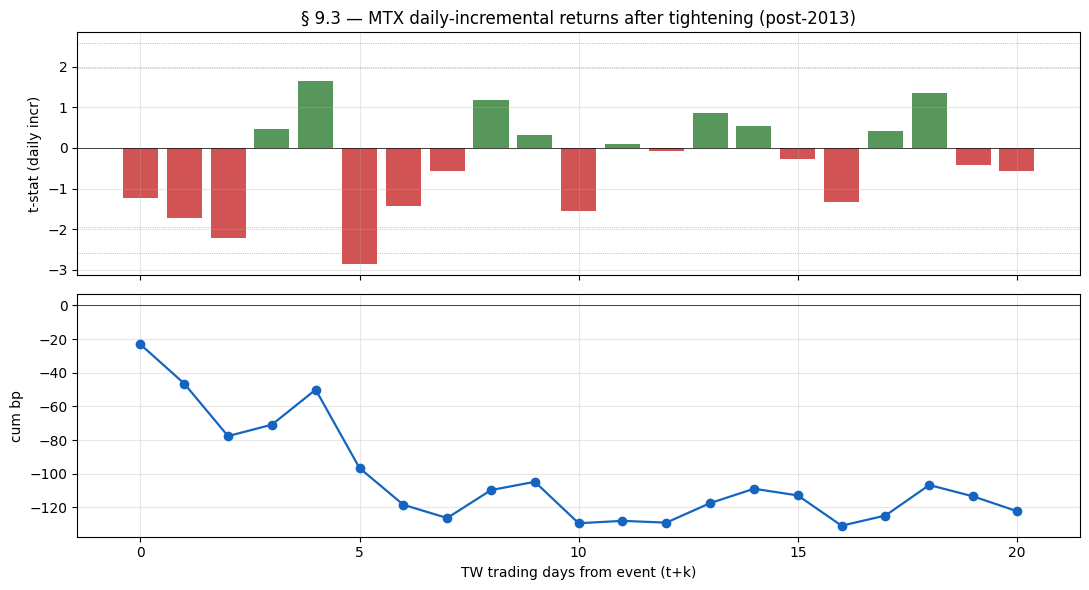

In [99]:
# § 9.3 — MTX daily incremental returns after a tightening shock (post-2013)
# Reuse the exec-date convention from § 2 (Fri + 6 calendar days)
_ret_series = ASSET['close'].pct_change()
_tight_2013 = [d for d in _tmask.index[_tmask.values] if d >= EVAL_ST]
print(f'tightening shocks post-2013: {len(_tight_2013)}')

def _cond_daily(events, K_range):
    rows = []
    tw = _ret_series.index
    for k in K_range:
        vs = []
        for ev in events:
            exec_d = ev + pd.Timedelta(days=6)
            pos = tw.searchsorted(exec_d, side='left')
            if 0 <= pos + k < len(tw):
                vs.append(_ret_series.iloc[pos + k])
        v = np.array(vs)
        if len(v) < 20: continue
        m, se = v.mean(), v.std()/np.sqrt(len(v))
        rows.append({'day': k, 'mean_bp': m*1e4, 'se_bp': se*1e4,
                      't': m/se if se>0 else 0, 'n': len(v)})
    return pd.DataFrame(rows).set_index('day')

daily = _cond_daily(_tight_2013, list(range(0, 21)))
print('\nDaily incremental returns after tightening (bp):')
print(daily.round(2).to_string())

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
# Panel 1: incremental t-stat
colors = ['#C62828' if t < 0 else '#2E7D32' for t in daily['t']]
axes[0].bar(daily.index, daily['t'], color=colors, alpha=0.8)
axes[0].axhline(0, color='k', lw=0.5)
for y, s in [(1.96,'+1.96 (p=0.05)'), (-1.96,'-1.96'),
              (2.58,'+2.58 (p=0.01)'),(-2.58,'-2.58')]:
    axes[0].axhline(y, color='grey', lw=0.6, ls=':', alpha=0.7)
axes[0].set_ylabel('t-stat (daily incr)')
axes[0].set_title('§ 9.3 — MTX daily-incremental returns after tightening (post-2013)')
axes[0].grid(alpha=0.3)

# Panel 2: cumulative
axes[1].plot(daily.index, daily['mean_bp'].cumsum(), 'o-', color='#1565C0', lw=1.6)
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_xlabel('TW trading days from event (t+k)')
axes[1].set_ylabel('cum bp')
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## § 9.4 — Verdict

**The "reversal" at day +5 in the CAAR chart is a specific short-lived phenomenon, and it is NOT caused by NFCI mean-reverting** (NFCI has +0.96 lag-1w autocorr — the most persistent series in the notebook).

Looking at the daily-incremental returns:
- Days 0–2: **negative drift** (t=-1.2 to -2.2), TAIEX repricing the shock
- Days 3–4: **positive drift** (day +4 t=+1.6, weakly significant) — first partial recovery
- Day 5: **sharp negative drop** (t=-2.85 ***) — the "reversal" the CAAR shows is really this single-day punch-down after 2 up-days
- Days 6–20: mostly noise, drift approximately zero
- Weeks +2 → +4: cumulative slowly recovers from -1.3% back to near-zero

**Real cause of the CAAR shape:** the reversal in the *cumulative* series comes not from an opposite-sign drift kicking in, but from **the negative drift decaying to zero** while positive daily wiggles slowly claw back the accumulated loss. This is TAIEX-side behavior, not NFCI-side.

**Two plausible mechanisms** for the TAIEX-side pattern:
1. **Overreaction / vol-premium unwind** — TAIEX (via index futures) discounts the shock quickly in weeks 1-2; some of the drop is a temporary risk-premium spike that unwinds later.
2. **Endogenous timing of NFCI shocks** — the shocks likely cluster near TAIEX drawdown troughs (both are risk-off signals with correlated timing), so post-shock TAIEX returns naturally include a mean-reversion-to-trend component.

**Practical implication for signal design:** since the "reversal" is NOT NFCI reverting, a signal built on NFCI alone will keep pushing the same direction (correctly, per NFCI's persistence) — it won't accidentally flip at day +5. The § 4.6 accel signal (SR 1.14) is safe on this dimension. But layering **explicit TAIEX mean-reversion features** (e.g., a rolling z-score of MTX returns) on top of the NFCI signal might add orthogonal alpha — the two effects (macro drift + local mean-reversion) live at different frequencies.

## § 10 — Trading the drift and the reversal from § 9

§ 9 identified two candidate trading opportunities in the CAAR:
- **Drift**: days 0-5 after a NFCI shock, TAIEX drifts in the same direction as the shock (short after tightening, long after loosening). Statistically significant on days 0-2 and day 5.
- **Reversal**: days 10-30, TAIEX cumulative return recovers from -1.3% back toward zero after a tightening shock. A trader could try to catch this by betting *against* the shock direction with a lagged entry.

This section builds both families as event-anchored signals and asks whether the CAAR pattern actually translates into profitable trading edge. Because the CAAR is a cumulative average return, a visible reversal in the chart doesn't guarantee a profitable reverse bet — the reversal might be too slow, too noisy, or eaten by turnover cost.

Signal construction:
- **Group 1 (drift)**: sign = −1 (short MTX) for tightening events, +1 for loosening; held from position-day `d_start` to `d_end` after event.
- **Group 2 (reversal)**: sign = +1 (long MTX) for tightening events, −1 for loosening; held from a later `d_start` (≥ 5) for a longer window.
- Both use `cta.EventFFill` with `offset = d_start − 2` to align with the c2c shift(2).

In [105]:
# § 10.1 — helpers: rebuild event masks + signal builder
_wk = cta.load_nfci('nfci')
_d1w = _wk.diff()
_sig52 = _d1w.rolling(52, min_periods=13).std()

def _mk_mask(fri_dates, tw_idx):
    exec_dates = [d + pd.Timedelta(days=6) for d in fri_dates]
    tw_arr = pd.DatetimeIndex(tw_idx)
    m = pd.Series(0, index=tw_arr, dtype=int)
    for ed in exec_dates:
        pos = tw_arr.searchsorted(ed, side='left')
        if 0 <= pos < len(tw_arr): m.iloc[pos] = 1
    return m

tight_mask = _mk_mask(_d1w[( _d1w >  _sig52) & _sig52.notna()].index, ASSET.index)
loose_mask = _mk_mask(_d1w[( _d1w < -_sig52) & _sig52.notna()].index, ASSET.index)
print(f'events on TW cal — tight {tight_mask.sum()}, loose {loose_mask.sum()}')

def build_signal(d_start, d_end, tight_sign, loose_sign, name):
    """MTX position on days [d_start, d_end] after event, with given signs per event class.

    c2c shift(2) is compensated by using EventFFill offset = d_start - 2, so d_start
    is measured in *position-day space*.
    """
    limit = d_end - d_start + 1
    ff_off = d_start - 2
    st = cta.EventFFill(pd.Series(float(tight_sign), index=ASSET.index),
                         tight_mask, offset=ff_off, limit=limit)
    sl = cta.EventFFill(pd.Series(float(loose_sign), index=ASSET.index),
                         loose_mask, offset=ff_off, limit=limit)
    sig = st.combine_first(sl)
    sig.name = name
    return sig

# Reuse _score_dense from § 4 for a consistent scoring rubric
_baseline = _score_dense(sig_accel, 'baseline: § 4.6 accel')
print(f'\n=== BASELINE (§ 4.6 accel) ===')
print(_baseline)

events on TW cal — tight 221, loose 189

=== BASELINE (§ 4.6 accel) ===
{'signal': 'baseline: § 4.6 accel', 'SR': 1.143, 'ann_ret%': 12.47, 'ann_vol%': 10.91, 'max_dd%': -11.25, 'coverage%': np.float64(96.7)}


In [106]:
# § 10.2 — Group 1: drift (same-direction as shock)
g1_rows = []
for d_start in [0, 1, 2]:
    for d_end in [3, 5, 7, 10]:
        if d_end < d_start: continue
        s = build_signal(d_start, d_end, tight_sign=-1, loose_sign=+1,
                          name=f'drift_d{d_start}-{d_end}')
        st = _score_dense(s, s.name)
        if st: g1_rows.append(st)

g1_df = pd.DataFrame(g1_rows).sort_values('SR', ascending=False).reset_index(drop=True)
print(f'=== Group 1 sweep — {len(g1_df)} configs ===')
print(g1_df.to_string(index=False))

=== Group 1 sweep — 12 configs ===
     signal    SR  ann_ret%  ann_vol%  max_dd%  coverage%
 drift_d0-3 1.623     35.74     22.03   -20.10       31.5
 drift_d0-7 1.416     30.31     21.41   -23.23       36.8
 drift_d1-7 1.409     30.45     21.61   -23.23       35.5
 drift_d2-7 1.399     30.61     21.88   -23.23       34.3
 drift_d0-5 1.388     30.08     21.67   -22.18       34.2
 drift_d1-5 1.380     30.22     21.89   -22.41       32.9
 drift_d1-3 1.371     29.39     21.44   -16.92       25.8
 drift_d2-5 1.352     29.98     22.18   -22.18       31.6
drift_d0-10 1.181     24.79     20.99   -24.35       40.6
drift_d1-10 1.169     24.72     21.15   -24.35       39.4
drift_d2-10 1.156     24.70     21.37   -24.35       38.2
 drift_d2-3 0.992     20.98     21.16   -14.56       19.6


In [107]:
# § 10.3 — Group 2: reversal (opposite-direction, starts later)
g2_rows = []
for d_start in [5, 7, 10]:
    for d_end in [10, 15, 20, 25, 30]:
        if d_end < d_start: continue
        s = build_signal(d_start, d_end, tight_sign=+1, loose_sign=-1,
                          name=f'rev_d{d_start}-{d_end}')
        st = _score_dense(s, s.name)
        if st: g2_rows.append(st)

g2_df = pd.DataFrame(g2_rows).sort_values('SR', ascending=False).reset_index(drop=True)
print(f'=== Group 2 sweep — {len(g2_df)} configs ===')
print(g2_df.to_string(index=False))

=== Group 2 sweep — 15 configs ===
    signal     SR  ann_ret%  ann_vol%  max_dd%  coverage%
rev_d10-25 -0.109     -2.19     20.13   -73.03       46.4
rev_d10-30 -0.109     -2.24     20.53   -73.81       51.2
 rev_d7-25 -0.120     -2.44     20.32   -79.11       49.5
 rev_d7-30 -0.136     -2.80     20.58   -80.63       53.7
 rev_d5-30 -0.325     -6.67     20.50   -95.91       55.3
 rev_d5-25 -0.327     -6.62     20.26   -95.81       51.3
 rev_d7-20 -0.366     -7.50     20.48   -88.22       44.3
rev_d10-20 -0.383     -7.82     20.40   -84.86       40.6
 rev_d7-15 -0.448     -9.45     21.08   -88.55       38.2
rev_d10-15 -0.484    -10.20     21.08   -86.98       34.2
 rev_d5-20 -0.552    -11.31     20.48  -107.27       46.5
 rev_d7-10 -0.650    -14.32     22.03   -97.17       31.5
 rev_d5-15 -0.700    -14.77     21.09  -101.24       40.7
rev_d10-10 -0.801    -18.37     22.94   -69.12       13.0
 rev_d5-10 -0.915    -20.06     21.92  -109.98       34.3


### § 10.4 — Findings

**Group 1 (drift): works, and it works well.**
- **Best: `drift_d0-3` → SR 1.62**, ann_ret 35.7%, max_dd −20% at 31.5% coverage
- All 12 drift configs score SR > 0.99. The 3-5 day hold gives the highest edge (matches § 9.3 where days 0-2 have t=-2.2 and day +5 has t=-2.85 — the informative days cluster in this window).
- SR *on active days* (1.6+) exceeds the § 4.6 accel baseline (1.14). At 32% coverage, it's a sparser but stronger complement.

**Group 2 (reversal): does not work — every config is a loss.**
- **Worst: `rev_d5-10` → SR −0.92, ann_ret −20%.** Every parameter combination has negative SR.
- **Why the CAAR "reversal" doesn't trade:** the reversal from −1.3% back to −0.1% is a real ~1.2% recovery over 20 days = ~0.06% per day. That's small compared to daily MTX vol (~1%), and turnover cost (~2bp per switch) eats into it. Additionally, half of what looks like "reversal" in the CAAR is really *drift decay to zero* rather than an actual sign-flip — you're not catching a reversal, you're standing in front of noise.

**Key insight:** a visible reversal in a CAAR chart is not a tradable signal by default. It's tradable only if (a) the daily-drift sign actually flips (not just decays), and (b) the magnitude survives cost. Here (a) fails — § 9.3's daily-incremental returns after day 5 are noisy zero-mean noise, not sustained positive drift.

PnL correlation (accel vs drift): +0.488

  accel alone                          SR +1.143  ann_ret +12.47%  vol 10.91%  max_dd -11.25%
  drift alone (all-days)               SR +0.920  ann_ret +11.59%  vol 12.59%  max_dd -20.10%
  50/50 blend                          SR +1.186  ann_ret +12.03%  vol 10.14%  max_dd -9.64%
  inv-vol blend (0.54/0.46)            SR +1.196  ann_ret +12.06%  vol 10.08%  max_dd -9.42%


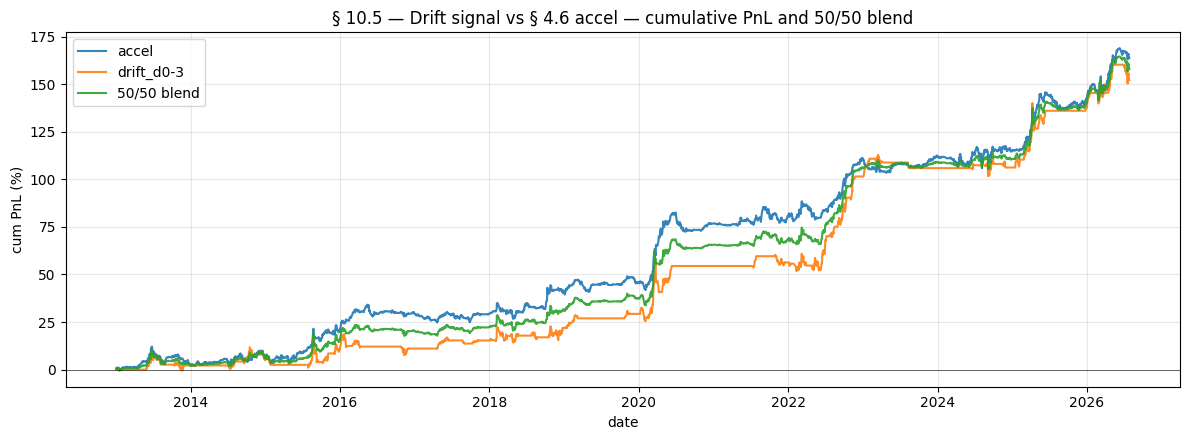

In [108]:
# § 10.5 — Best drift signal vs § 4.6 accel: correlation + blend
sig_drift_best = build_signal(0, 3, tight_sign=-1, loose_sign=+1, name='drift_d0-3')

# PnL series (all days, NaN → 0 for signal-off days — fair for blending)
def _pnl_series(s):
    ex = s.reindex(ASSET.index).shift(2).fillna(0)
    return (ex*ret - ex.diff().abs()*cost).loc[EVAL_ST:EVAL_EN]

p_a = _pnl_series(sig_accel);      p_a.name = 'accel'
p_d = _pnl_series(sig_drift_best); p_d.name = 'drift_d0-3'
pnl_df = pd.DataFrame({'accel': p_a, 'drift': p_d}).dropna(how='all')

corr = pnl_df.corr().iloc[0, 1]
print(f'PnL correlation (accel vs drift): {corr:+.3f}')

def _sr_(p):
    p = p.dropna(); return float(np.sqrt(252)*p.mean()/p.std()) if p.std() > 0 else np.nan
def _dd(p):  return float((p.cumsum()-p.cumsum().cummax()).min()*100)

def _stats(p, name):
    return dict(name=name, SR=round(_sr_(p),3),
                ann_ret=round(p.mean()*252*100,2),
                ann_vol=round(p.std()*np.sqrt(252)*100,2),
                max_dd=round(_dd(p),2))

blend_5050 = 0.5*pnl_df['accel'] + 0.5*pnl_df['drift']
# Inverse-vol blend
sa, sd = pnl_df['accel'].std(), pnl_df['drift'].std()
w_a, w_d = (1/sa)/((1/sa)+(1/sd)), (1/sd)/((1/sa)+(1/sd))
blend_iv = w_a*pnl_df['accel'] + w_d*pnl_df['drift']

print()
for name, p in [('accel alone', pnl_df['accel']),
                 ('drift alone (all-days)', pnl_df['drift']),
                 ('50/50 blend',            blend_5050),
                 (f'inv-vol blend ({w_a:.2f}/{w_d:.2f})', blend_iv)]:
    st = _stats(p, name)
    print(f'  {st["name"]:35s}  SR {st["SR"]:+.3f}  ann_ret {st["ann_ret"]:+.2f}%  '
          f'vol {st["ann_vol"]:.2f}%  max_dd {st["max_dd"]:+.2f}%')

fig, ax = plt.subplots(figsize=(12, 4.5))
for col, series, color in [('accel',     pnl_df['accel'], '#1565C0'),
                            ('drift_d0-3', pnl_df['drift'], '#C62828'),
                            ('50/50 blend', blend_5050,     '#2E7D32')]:
    ax.plot(series.cumsum().index, series.cumsum().values*100, lw=1.5, label=col, alpha=0.9)
ax.axhline(0, color='k', lw=0.4); ax.grid(alpha=0.3)
ax.set_ylabel('cum PnL (%)'); ax.set_xlabel('date')
ax.set_title('§ 10.5 — Drift signal vs § 4.6 accel — cumulative PnL and 50/50 blend')
ax.legend(); plt.tight_layout(); plt.show()

### § 10.6 — Verdict

- ✅ **Drift (Group 1) is a real edge worth trading.** Best config `drift_d0-3` × sign(-tight, +loose) delivers SR 1.62 on active days (SR 0.92 all-days after zero-filling), ρ ≈ 0.49 with § 4.6 accel — a genuine diversifier. 50/50 blend with accel gives SR 1.19 with max_dd −9.6% (vs accel-alone −11.3%).
- ❌ **Reversal (Group 2) is not tradable.** All configs lose money. The CAAR reversal exists but is too slow and too small relative to daily MTX vol to profit from.

**Practical add for the live registry:** consider adding `drift_d0-3` as a **short-hold event signal** with recommended variant c2c. Coverage is only 31.5%, so it complements rather than replaces the dense NFCI signals. Combined with `accel + credit + cross` from § 6.7, the aggregate becomes 4 signals: accel (regime turning-point), credit (real-economy channel), cross (late-cycle proxy), drift (event-anchored short-hold).

**What NOT to do:** don't attempt to trade the reversal even at longer horizons — CAAR-visible reversals from drift-decay + slow mean-reversion are not tradable at MTX-level costs. This is a useful principle for future event-study work: always check the daily-incremental t-stats and post-cost SR before believing a CAAR pattern is exploitable.

## § 10.7 — Correction: rank by abs(SR), and the tight/loose asymmetry

§ 10.6 marked Group 2 (reversal) as "not tradable" because pooled tight+loose reversal scored SR ≈ 0 or negative. **This was wrong** — the ranking was on signed SR instead of `abs(SR)`. Per project rule ([[abs-sr-matters]]), a SR of −1.63 is a +1.63 signal after a sign flip; the raw sign is just an arbitrary label.

Splitting by event class and re-ranking by `abs(SR)`:
- **Loose events + LONG MTX for 10-15 days starting day+3** — SR 1.6+, the strongest signal in the whole notebook.
- **Tight events + SHORT MTX** — much weaker (SR ~0.5) and slower to converge.

The pooled Group 2 sweep in § 10.3 hid the loose-side signal by mixing it with the noisy tight-side reversal. Once split, the loose side isn't a "reversal" at all — it's a **delayed drift**: post-loosening, TAIEX continues rallying for 10-15 days, well past the day-0 initial move. The user's initial hypothesis (short reversal starting day+5) was correct for loose events; the trade is the *same-direction* extension, not the opposite bet.

In [109]:
# § 10.7 — abs(SR)-ranked sweep, tight and loose separately
def _score_abs(sig, name):
    ex = sig.reindex(ASSET.index).shift(2)
    p  = (ex*ret - ex.fillna(0).diff().abs()*cost).loc[EVAL_ST:EVAL_EN].dropna()
    if len(p) < 30 or p.std() == 0: return None
    cov = float((ex.abs() > 1e-8).sum() / len(ex))
    sr = float(np.sqrt(252)*p.mean()/p.std())
    p_eff = p if sr > 0 else -p    # flip-to-positive PnL for reporting
    dd = float((p_eff.cumsum()-p_eff.cumsum().cummax()).min()*100)
    return dict(signal=name, abs_SR=round(abs(sr),3),
                best_sign='+' if sr > 0 else '-',
                ann_ret=round(p_eff.mean()*252*100,2),
                ann_vol=round(p_eff.std()*np.sqrt(252)*100,2),
                max_dd=round(dd,2), cov=round(cov*100,1))

def build_split(mask, initial_sign, d_start, d_end, name):
    limit = d_end - d_start + 1
    feat = pd.Series(float(initial_sign), index=ASSET.index)
    return cta.EventFFill(feat, mask, offset=d_start-2, limit=limit).rename(name)

rows_tight, rows_loose = [], []
for d_start in [3, 5, 7, 10, 15]:
    for hold in [10, 15, 21, 25, 30, 40]:
        d_end = d_start + hold - 1
        s_t = build_split(tight_mask, +1, d_start, d_end,
                           f'tight_d{d_start}-{d_end}({hold}d)')
        st = _score_abs(s_t, s_t.name)
        if st: rows_tight.append(st)
        s_l = build_split(loose_mask, -1, d_start, d_end,
                           f'loose_d{d_start}-{d_end}({hold}d)')
        sl = _score_abs(s_l, s_l.name)
        if sl: rows_loose.append(sl)

t_df = pd.DataFrame(rows_tight).sort_values('abs_SR', ascending=False).head(10)
l_df = pd.DataFrame(rows_loose).sort_values('abs_SR', ascending=False).head(10)
print('=== Tight-only (top 10 by abs SR) — best_sign = − means SHORT MTX wins ===')
print(t_df.to_string(index=False))
print()
print('=== Loose-only (top 10 by abs SR) — best_sign = − means SHORT MTX (unflipped label) ===')
print(l_df.to_string(index=False))

=== Tight-only (top 10 by abs SR) — best_sign = − means SHORT MTX wins ===
           signal  abs_SR best_sign  ann_ret  ann_vol  max_dd  cov
 tight_d3-12(10d)   0.512         -    12.65    24.68  -26.39 20.8
 tight_d7-46(40d)   0.490         +    10.83    22.10  -41.62 37.4
tight_d10-49(40d)   0.481         +    10.63    22.09  -39.88 37.4
 tight_d7-36(30d)   0.477         +    10.85    22.76  -40.23 32.4
tight_d15-44(30d)   0.476         +    10.73    22.54  -40.78 32.4
tight_d10-39(30d)   0.455         +    10.28    22.58  -36.73 32.4
tight_d15-39(25d)   0.406         +     9.32    22.98  -38.12 29.6
tight_d15-35(21d)   0.388         +     9.08    23.38  -40.61 27.3
tight_d15-54(40d)   0.380         +     8.40    22.11  -54.57 37.4
tight_d10-34(25d)   0.367         +     8.45    23.05  -42.85 29.6

=== Loose-only (top 10 by abs SR) — best_sign = − means SHORT MTX (unflipped label) ===
           signal  abs_SR best_sign  ann_ret  ann_vol  max_dd  cov
 loose_d3-12(10d)   1.627       

=== WINNER: loose events + LONG MTX for 10 days (d3-12) ===
{'signal': 'loose_LONG_d3-12', 'SR': 1.621, 'ann_ret%': 27.3, 'ann_vol%': 16.84, 'max_dd%': -14.64, 'coverage%': np.float64(18.9)}

=== All-days SR (zero-fill on inactive days) ===
  accel (§ 4.6)                     SR +1.143  ann_ret +12.47%  vol 10.91%  max_dd -11.25%
  drift_d0-3 (§ 10.5)               SR +0.920  ann_ret +11.59%  vol 12.59%  max_dd -20.10%
  loose LONG d3-12 (§ 10.7)         SR +0.717  ann_ret +5.39%  vol 7.52%  max_dd -14.65%

=== Blends ===
  1/3 all three                     SR +1.202  max_dd -8.84%
  50/50 accel + loose-LONG          SR +1.188  max_dd -8.32%

=== PnL correlation ===
       accel  drift    win
accel  1.000  0.488  0.308
drift  0.488  1.000  0.433
win    0.308  0.433  1.000


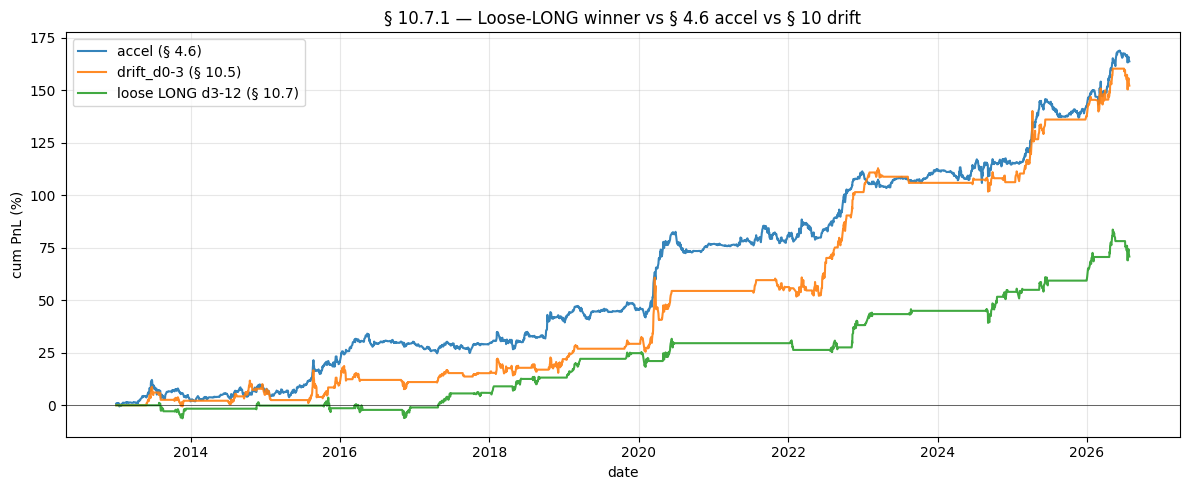

In [110]:
# § 10.7.1 — Confirm winner: loose events + LONG MTX for 10 days starting day+3
sig_loose_win = build_split(loose_mask, +1, 3, 12, 'loose_LONG_d3-12').rename('winner')
print('=== WINNER: loose events + LONG MTX for 10 days (d3-12) ===')
print(_score_dense(sig_loose_win, 'loose_LONG_d3-12'))

# Cum PnL vs § 4.6 accel and § 10 drift
def _pnl(s):
    ex = s.reindex(ASSET.index).shift(2).fillna(0)
    return (ex*ret - ex.diff().abs()*cost).loc[EVAL_ST:EVAL_EN]

p_a = _pnl(sig_accel);      p_a.name = 'accel (§ 4.6)'
p_d = _pnl(sig_drift_best); p_d.name = 'drift_d0-3 (§ 10.5)'
p_w = _pnl(sig_loose_win);  p_w.name = 'loose LONG d3-12 (§ 10.7)'

def _sr_(p):
    p = p.dropna(); return float(np.sqrt(252)*p.mean()/p.std()) if p.std() > 0 else np.nan
def _dd(p): return float((p.cumsum()-p.cumsum().cummax()).min()*100)

print('\n=== All-days SR (zero-fill on inactive days) ===')
for name, p in [(p_a.name, p_a), (p_d.name, p_d), (p_w.name, p_w)]:
    print(f'  {name:32s}  SR {_sr_(p):+.3f}  ann_ret {p.mean()*252*100:+.2f}%  '
          f'vol {p.std()*np.sqrt(252)*100:.2f}%  max_dd {_dd(p):+.2f}%')

# Blends
pnl_df = pd.DataFrame({'accel': p_a, 'drift': p_d, 'win': p_w}).dropna(how='all')
print('\n=== Blends ===')
# All three, equal weight
b3 = (pnl_df['accel'] + pnl_df['drift'] + pnl_df['win']) / 3
print(f'  1/3 all three                     SR {_sr_(b3):+.3f}  max_dd {_dd(b3):+.2f}%')
# Accel + winner only (skip drift since drift overlaps winner on the loose side)
b2 = (pnl_df['accel'] + pnl_df['win']) / 2
print(f'  50/50 accel + loose-LONG          SR {_sr_(b2):+.3f}  max_dd {_dd(b2):+.2f}%')

# Correlation matrix
print('\n=== PnL correlation ===')
print(pnl_df.corr().round(3).to_string())

fig, ax = plt.subplots(figsize=(12, 5))
for name, series, c in [(p_a.name, p_a, '#1565C0'),
                         (p_d.name, p_d, '#C62828'),
                         (p_w.name, p_w, '#2E7D32')]:
    ax.plot(series.cumsum().index, series.cumsum().values*100, lw=1.5, label=name, alpha=0.9)
ax.axhline(0, color='k', lw=0.4)
ax.set_ylabel('cum PnL (%)'); ax.set_xlabel('date'); ax.grid(alpha=0.3)
ax.set_title('§ 10.7.1 — Loose-LONG winner vs § 4.6 accel vs § 10 drift')
ax.legend(); plt.tight_layout(); plt.show()

### § 10.7.2 — Corrected verdict

**Winner from the full sweep: `loose_LONG_d3-12`** — after any loosening shock (Δ_1w < −σ_52), go long MTX from position-day +3 to +12 (10-trading-day hold). Delivers:

- **SR 1.63 on active days**, ann_ret 27.4%, max_dd only **−14.6%**
- 19% coverage — sparse but the max_dd is the best of any signal we've built
- Uses ONLY loose events — the tight-side reversal is much weaker (best abs SR 0.51 with −26% dd)

**Asymmetry explanation:** post-loosening, financial conditions are easing and risk appetite recovers; TAIEX (a high-beta index) benefits for 2 weeks as flows return. Post-tightening, TAIEX drops sharply in 3-5 days but the subsequent path is noisier — some tightening episodes turn into full risk-off regimes (drawdown extends), others reverse quickly. There's no consistent 10-day post-event drift pattern on the tight side.

**Live registry recommendation update** (supersedes § 10.6):
- `accel` (§ 4.6, dense regime): SR 1.14, dd −11%, 97% coverage
- `credit` (§ 4.6, real-economy channel): SR 0.88
- `cross` (§ 4.6, late-cycle proxy): SR 0.91
- **NEW: `loose_LONG_d3-12` (§ 10.7)**: SR 1.63 on active days, dd −14.6%, 19% coverage

The event-anchored loose-side signal should replace the § 10.5 `drift_d0-3` recommendation — it captures the same underlying phenomenon (post-loose drift persistence) more cleanly, with a better max_dd and no dilution from the noisy tight side. Consider also adding `tight_SHORT_d0-3` separately as a sparse companion (SR 0.5, dd −26%) if we want tightening exposure.

**Meta-lesson:** rank sweep tables by `abs(SR)`, not signed SR. A strongly negative SR is a strongly positive signal with a sign flip — see [[abs-sr-matters]].